In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df1 = pd.read_excel('附件1.xlsx')
df1

,单品编码,单品名称,分类编码,分类名称
0,102900005115168,牛首生菜,1011010101,花叶类
1,102900005115199,四川红香椿,1011010101,花叶类
2,102900005115625,本地小毛白菜,1011010101,花叶类
3,102900005115748,白菜苔,1011010101,花叶类
4,102900005115762,苋菜,1011010101,花叶类
...,...,...,...,...
246,106958851400125,海鲜菇(袋)(4),1011010801,食用菌
247,106971533450003,海鲜菇(包),1011010801,食用菌
248,106971533455008,海鲜菇(袋)(3),1011010801,食用菌
249,106973223300667,虫草花(盒)(2),1011010801,食用菌


In [7]:
# 单品编码到分类名称的映射
dpbm_to_flmc = df1.set_index('单品编码')['分类名称'].to_dict()
dpbm_to_flmc

{102900005115168: '花叶类',
 102900005115199: '花叶类',
 102900005115625: '花叶类',
 102900005115748: '花叶类',
 102900005115762: '花叶类',
 102900005115779: '花叶类',
 102900005115786: '花叶类',
 102900005115793: '花叶类',
 102900005115816: '花叶类',
 102900005115823: '花叶类',
 102900005115854: '花叶类',
 102900005115861: '花叶类',
 102900005115878: '花叶类',
 102900005115885: '花叶类',
 102900005115908: '花叶类',
 102900005115946: '花叶类',
 102900005115960: '花叶类',
 102900005115977: '花叶类',
 102900005115984: '花叶类',
 102900005116639: '花叶类',
 102900005116776: '花叶类',
 102900005116790: '花叶类',
 102900005116806: '花叶类',
 102900005118572: '花叶类',
 102900005118817: '花叶类',
 102900005118831: '花叶类',
 102900005119975: '花叶类',
 102900005122654: '花叶类',
 102900005128748: '花叶类',
 102900011000175: '花叶类',
 102900011000571: '花叶类',
 102900011002414: '花叶类',
 102900011006689: '花叶类',
 102900011006948: '花叶类',
 102900011006955: '花叶类',
 102900011007464: '花叶类',
 102900011007471: '花叶类',
 102900011007495: '花叶类',
 102900011008133: '花叶类',
 102900011008164: '花叶类',


In [8]:
df2 = pd.read_excel('附件2.xlsx')
df2

,销售日期,扫码销售时间,单品编码,销量(千克),销售单价(元/千克),销售类型,是否打折销售
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,销售,否
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,销售,否
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,销售,否
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,销售,否
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,销售,否
...,...,...,...,...,...,...,...
878498,2023-06-30,21:35:13.264,102900005115250,0.284,24.0,销售,否
878499,2023-06-30,21:35:14.358,102900011022764,0.669,12.0,销售,否
878500,2023-06-30,21:35:20.264,102900005115250,0.125,24.0,销售,否
878501,2023-06-30,21:35:21.509,102900011016701,0.252,5.2,销售,否


In [9]:
# 计算各品类日销售量
from tqdm import tqdm
# 获取所有日期
all_dates = df2['销售日期'].unique()

# 获取所有商品分类名称，并去重
all_categories = list(set(dpbm_to_flmc.values()))  # 使用set去重
print(f"共有 {len(all_categories)} 个不同的分类")

# 创建初始DataFrame，所有销量初始化为0
daily_sales = pd.DataFrame(
    0,  # 初始值
    index=range(len(all_dates)),
    columns=['日期'] + all_categories  # 列：日期 + 所有分类
)

# 填充日期列
daily_sales['日期'] = all_dates

# 填充各品类的销量数据
for index, row in tqdm(df2.iterrows(), total=df2.shape[0]):
    date = row['销售日期']
    category = dpbm_to_flmc[row['单品编码']]
    sales = row['销量(千克)']
    daily_sales.loc[daily_sales['日期'] == date, category] += sales

daily_sales.head()

共有 6 个不同的分类


  0%|          | 0/878503 [00:00<?, ?it/s]D:\TEMP\USER_TEMP\ipykernel_11604\4177222061.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.396]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  daily_sales.loc[daily_sales['日期'] == date, category] += sales
  0%|          | 1/878503 [00:00<164:48:40,  1.48it/s]D:\TEMP\USER_TEMP\ipykernel_11604\4177222061.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.849]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  daily_sales.loc[daily_sales['日期'] == date, category] += sales
D:\TEMP\USER_TEMP\ipykernel_11604\4177222061.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.251]' has dtype incompatible with int6

,日期,辣椒类,水生根茎类,茄类,花叶类,食用菌,花菜类
0,2020-07-01,76.715,4.850,35.374,205.402,35.365,46.640
1,2020-07-02,66.064,4.600,32.199,198.362,48.510,43.943
2,2020-07-03,64.253,9.572,35.896,190.779,42.442,42.076
3,2020-07-04,81.282,5.439,57.067,236.587,47.262,55.662
4,2020-07-05,98.496,4.019,61.816,223.899,73.213,55.474


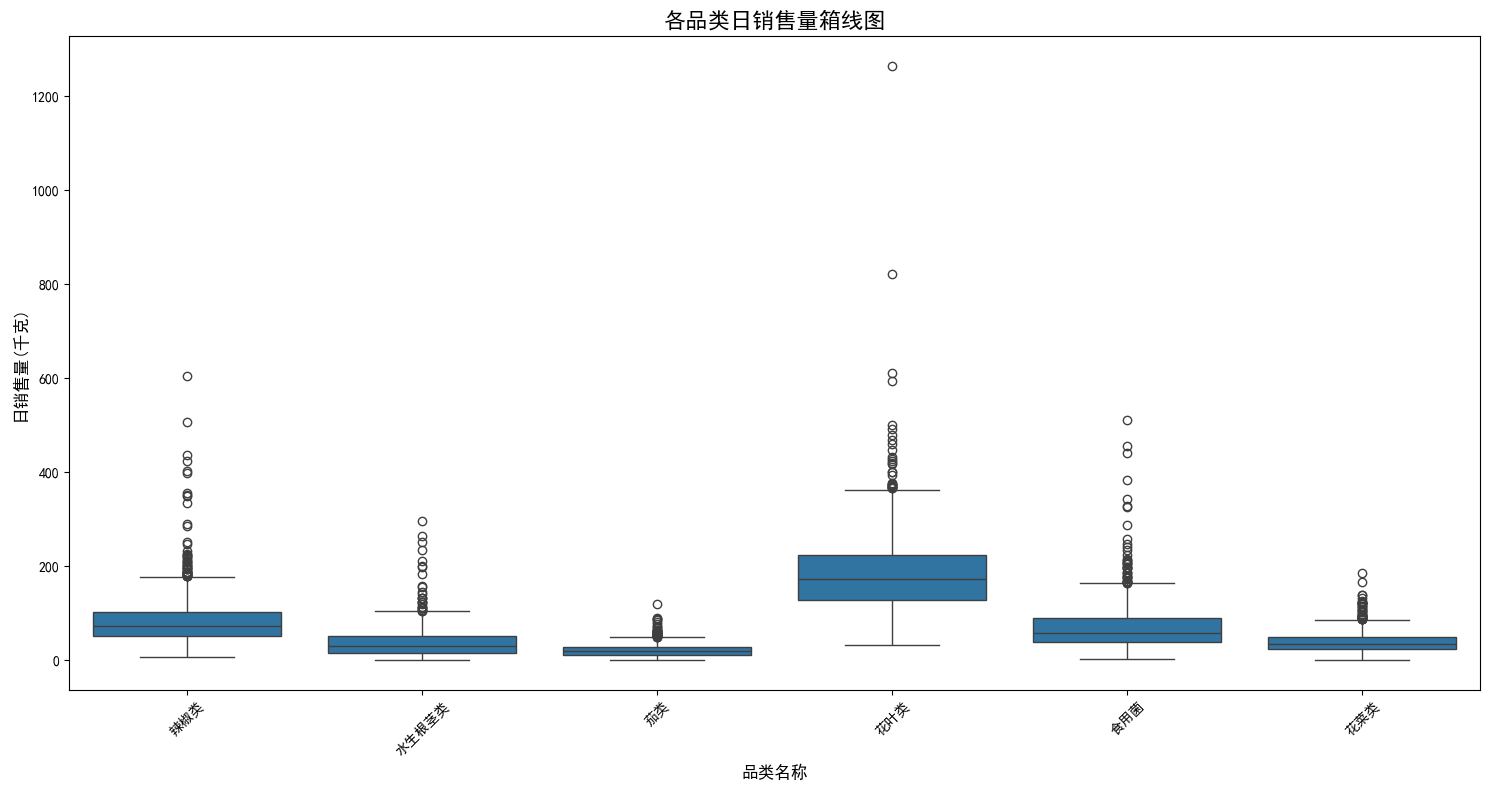

各品类日销售量统计信息：

辣椒类:
  平均值: 84.41
  中位数: 72.92
  最大值: 604.23
  最小值: 6.07

水生根茎类:
  平均值: 37.40
  中位数: 30.19
  最大值: 296.79
  最小值: 0.93

茄类:
  平均值: 20.67
  中位数: 18.30
  最大值: 118.93
  最小值: 0.00

花叶类:
  平均值: 182.97
  中位数: 173.19
  最大值: 1265.47
  最小值: 31.30

食用菌:
  平均值: 70.13
  中位数: 57.53
  最大值: 511.14
  最小值: 3.01

花菜类:
  平均值: 38.49
  中位数: 34.07
  最大值: 186.16
  最小值: 0.00


In [10]:
# 画出各品类日销售量箱线图
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 准备箱线图数据 - 将宽表转换为长表
# 排除日期列，只保留销售量数据
sales_data = []
category_names = []

for category in all_categories:
    if category in daily_sales.columns:
        sales_values = daily_sales[category].values
        sales_data.extend(sales_values)
        category_names.extend([category] * len(sales_values))

# 创建DataFrame用于绘图
plot_data = pd.DataFrame({
    '分类名称': category_names,
    '日销售量(千克)': sales_data
})

# 绘制箱线图
plt.figure(figsize=(15, 8))
sns.boxplot(data=plot_data, x='分类名称', y='日销售量(千克)')
plt.title('各品类日销售量箱线图', fontsize=16)
plt.xlabel('品类名称', fontsize=12)
plt.ylabel('日销售量(千克)', fontsize=12)
plt.xticks(rotation=45)  # 旋转x轴标签
plt.tight_layout()
plt.show()

# 显示基本统计信息
print("各品类日销售量统计信息：")
for category in all_categories:  # 显示所有品类的统计
    if category in daily_sales.columns:
        stats = daily_sales[category].describe()
        print(f"\n{category}:")
        print(f"  平均值: {stats['mean']:.2f}")
        print(f"  中位数: {stats['50%']:.2f}")
        print(f"  最大值: {stats['max']:.2f}")
        print(f"  最小值: {stats['min']:.2f}")

开始对各品类进行异常值处理:

处理品类: 辣椒类
辣椒类: 去除了 50 个异常值 (总数据量: 1085)
  异常值边界: [-25.09, 178.46]

处理品类: 水生根茎类
水生根茎类: 去除了 27 个异常值 (总数据量: 1085)
  异常值边界: [-38.59, 104.47]

处理品类: 茄类
茄类: 去除了 35 个异常值 (总数据量: 1085)
  异常值边界: [-11.08, 49.58]

处理品类: 花叶类
花叶类: 去除了 29 个异常值 (总数据量: 1085)
  异常值边界: [-13.52, 365.73]

处理品类: 食用菌
食用菌: 去除了 40 个异常值 (总数据量: 1085)
  异常值边界: [-35.64, 164.09]

处理品类: 花菜类
花菜类: 去除了 40 个异常值 (总数据量: 1085)
  异常值边界: [-14.52, 86.34]

异常值处理效果总结:
数据行数变化: 1085 -> 961 (删除了 124 个异常日期)

辣椒类:
  有销量天数: 1085 -> 961 (减少124天)
  平均销量: 84.41 -> 75.05
  最大销量: 604.23 -> 174.43

水生根茎类:
  有销量天数: 1085 -> 961 (减少124天)
  平均销量: 37.40 -> 32.48
  最大销量: 296.79 -> 104.46

茄类:
  有销量天数: 1050 -> 933 (减少117天)
  平均销量: 20.67 -> 19.20
  最大销量: 118.93 -> 49.50

花叶类:
  有销量天数: 1085 -> 961 (减少124天)
  平均销量: 182.97 -> 168.48
  最大销量: 1265.47 -> 360.32

食用菌:
  有销量天数: 1085 -> 961 (减少124天)
  平均销量: 70.13 -> 61.50
  最大销量: 511.14 -> 163.66

花菜类:
  有销量天数: 1084 -> 960 (减少124天)
  平均销量: 38.49 -> 34.12
  最大销量: 186.16 -> 85.40

总计去除异常值天数: 124
数据形状变化: (1085

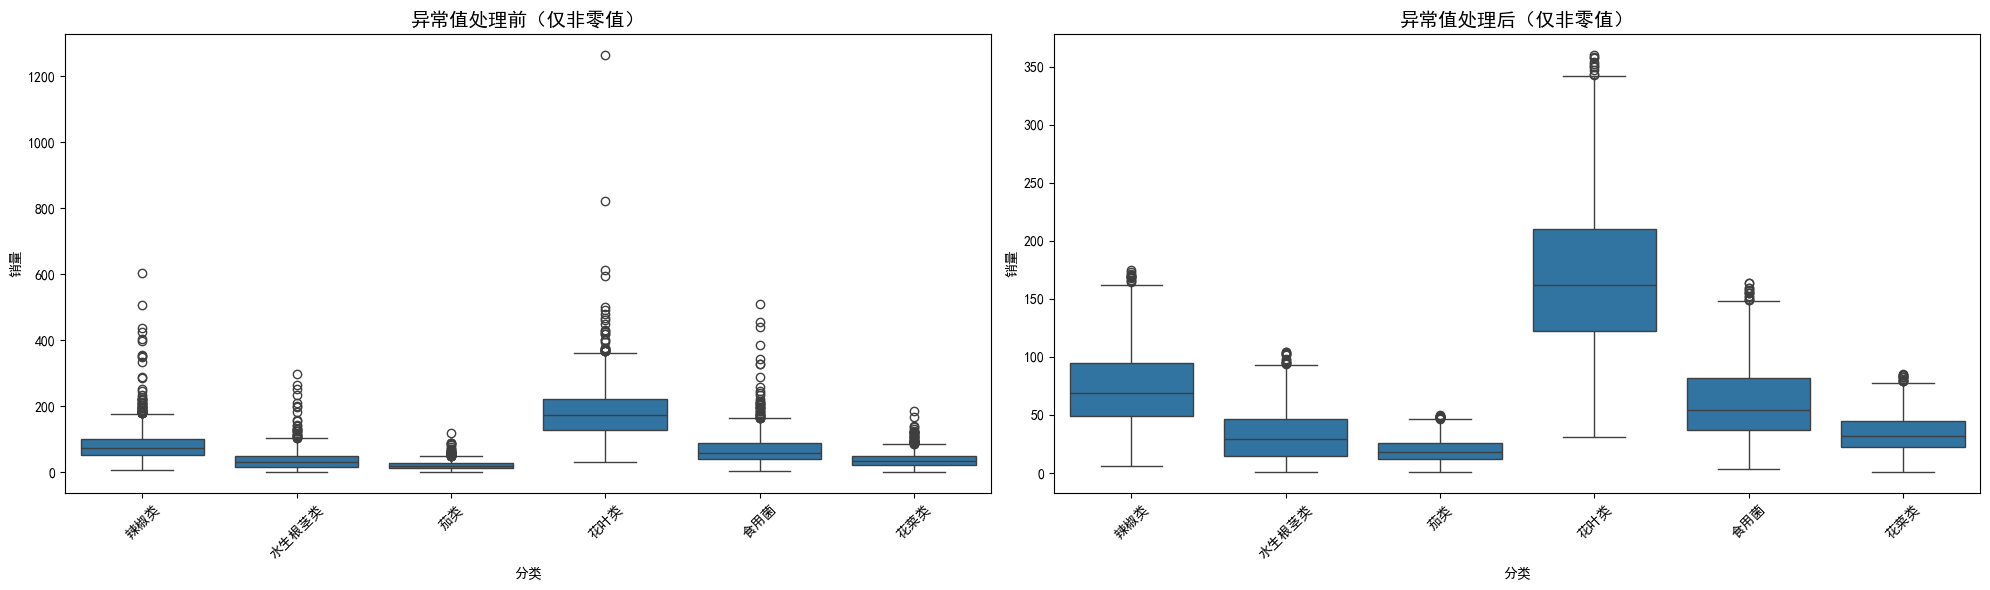


✅ 异常值处理完成！清洗后的数据存储在 daily_sales_cleaned 中


In [11]:
# 使用箱线图去除异常值
def remove_outliers_boxplot(data, column):
    """
    使用箱线图方法去除异常值（IQR方法）
    异常值定义：小于Q1-1.5*IQR 或 大于Q3+1.5*IQR
    """
    Q1 = data[column].quantile(0.25)  # 第一四分位数
    Q3 = data[column].quantile(0.75)  # 第三四分位数
    IQR = Q3 - Q1  # 四分位距
    
    # 定义异常值的边界
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 去除异常值
    filtered_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    
    outliers_count = len(data) - len(filtered_data)
    print(f"{column}: 去除了 {outliers_count} 个异常值 (总数据量: {len(data)})")
    print(f"  异常值边界: [{lower_bound:.2f}, {upper_bound:.2f}]")
    
    return filtered_data

# 对每个品类进行异常值处理
daily_sales_cleaned = daily_sales.copy()
total_outliers_removed = 0

print("开始对各品类进行异常值处理:")
print("=" * 60)

for category in all_categories:
    if category in daily_sales.columns:
        print(f"\n处理品类: {category}")
        
        # 创建临时DataFrame用于异常值检测
        temp_data = pd.DataFrame({
            '日期': daily_sales['日期'],
            category: daily_sales[category]
        })
        
        # 去除异常值
        cleaned_temp = remove_outliers_boxplot(temp_data, category)
        
        # 只保留cleaned_temp中的日期对应的行
        daily_sales_cleaned = daily_sales_cleaned[daily_sales_cleaned['日期'].isin(cleaned_temp['日期'])].reset_index(drop=True)
        
        outliers_removed = len(daily_sales) - len(daily_sales_cleaned)
        total_outliers_removed = outliers_removed

print("\n" + "="*80)
print("异常值处理效果总结:")
print("="*80)

# 统计异常值处理前后的变化
print(f"数据行数变化: {len(daily_sales)} -> {len(daily_sales_cleaned)} (删除了 {len(daily_sales) - len(daily_sales_cleaned)} 个异常日期)")

for category in all_categories:
    if category in daily_sales.columns and category in daily_sales_cleaned.columns:
        original_nonzero = (daily_sales[category] > 0).sum()
        cleaned_nonzero = (daily_sales_cleaned[category] > 0).sum()
        outliers_in_category = original_nonzero - cleaned_nonzero
        
        original_stats = daily_sales[category].describe()
        cleaned_stats = daily_sales_cleaned[category].describe()
        
        print(f"\n{category}:")
        print(f"  有销量天数: {original_nonzero} -> {cleaned_nonzero} (减少{outliers_in_category}天)")
        print(f"  平均销量: {original_stats['mean']:.2f} -> {cleaned_stats['mean']:.2f}")
        print(f"  最大销量: {original_stats['max']:.2f} -> {cleaned_stats['max']:.2f}")

print(f"\n总计去除异常值天数: {total_outliers_removed}")
print(f"数据形状变化: {daily_sales.shape} -> {daily_sales_cleaned.shape} (处理方式: 删除异常值行)")

# 绘制清洗后的箱线图对比（简化版）
plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)
# 原始数据箱线图 - 只显示非零值
original_plot_data = []
category_names = []
for category in all_categories:
    if category in daily_sales.columns:
        nonzero_values = daily_sales[daily_sales[category] > 0][category].values
        original_plot_data.extend(nonzero_values)
        category_names.extend([category] * len(nonzero_values))

plot_df_original = pd.DataFrame({
    '分类': category_names,
    '销量': original_plot_data
})

sns.boxplot(data=plot_df_original, x='分类', y='销量')
plt.title('异常值处理前（仅非零值）', fontsize=14)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
# 清洗后数据箱线图 - 只显示非零值
cleaned_plot_data = []
category_names = []
for category in all_categories:
    if category in daily_sales_cleaned.columns:
        nonzero_values = daily_sales_cleaned[daily_sales_cleaned[category] > 0][category].values
        cleaned_plot_data.extend(nonzero_values)
        category_names.extend([category] * len(nonzero_values))

plot_df_cleaned = pd.DataFrame({
    '分类': category_names,
    '销量': cleaned_plot_data
})

sns.boxplot(data=plot_df_cleaned, x='分类', y='销量')
plt.title('异常值处理后（仅非零值）', fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"\n✅ 异常值处理完成！清洗后的数据存储在 daily_sales_cleaned 中")
daily_sales_cleaned.to_excel('清洗后的日销售量.xlsx', index=False)

In [23]:
# 附件二-预处理：删除异常值并保存为原始附件二格式

print("开始处理附件二数据，删除异常值...")
print("=" * 60)

# 1. 首先获取异常值处理后保留的日期列表
valid_dates = set(daily_sales_cleaned['日期'])
print(f"异常值处理后保留的有效日期数量: {len(valid_dates)}")

# 2. 从原始df2中筛选出有效日期的数据
df2_cleaned = df2[df2['销售日期'].isin(valid_dates)].copy()

# 3. 添加分类名称列
df2_cleaned['分类名称'] = df2_cleaned['单品编码'].map(dpbm_to_flmc)

print(f"原始附件二数据量: {len(df2)} 条记录")
print(f"清洗后附件二数据量: {len(df2_cleaned)} 条记录")
print(f"删除了 {len(df2) - len(df2_cleaned)} 条异常值记录")
print(f"已添加分类名称列")

# 3. 检查数据完整性
print(f"\n数据完整性检查:")
print(f"原始数据日期范围: {df2['销售日期'].min()} 到 {df2['销售日期'].max()}")
print(f"清洗后数据日期范围: {df2_cleaned['销售日期'].min()} 到 {df2_cleaned['销售日期'].max()}")
print(f"清洗后数据列名: {list(df2_cleaned.columns)}")

# 按品类统计清洗前后的数据量变化
print(f"\n各品类数据量变化:")
print("-" * 50)
for category in all_categories:
    original_count = len(df2[df2['单品编码'].map(dpbm_to_flmc) == category])
    cleaned_count = len(df2_cleaned[df2_cleaned['分类名称'] == category])  # 使用新增的分类名称列
    reduction = original_count - cleaned_count
    reduction_pct = (reduction / original_count * 100) if original_count > 0 else 0
    
    print(f"{category:12}: {original_count:6} -> {cleaned_count:6} (减少 {reduction:4} 条, {reduction_pct:.1f}%)")

# 4. 保存清洗后的附件二数据
output_filename = '附件二-预处理.xlsx'
df2_cleaned.to_excel(output_filename, index=False)

print(f"\n✅ 附件二预处理完成！")
print(f"📁 清洗后的数据已保存到: {output_filename}")
print(f"📊 数据格式与原始附件二完全一致，仅删除了异常值对应的记录")

# 5. 验证保存的数据
print(f"\n保存数据验证:")
verification_df = pd.read_excel(output_filename)
print(f"保存文件数据量: {len(verification_df)} 条记录")
print(f"列名: {list(verification_df.columns)}")
print(f"前5行数据预览:")
print(verification_df.head())

# 6. 统计各品类在清洗后数据中的销售总量
print(f"\n各品类清洗后总销售量统计:")
print("-" * 50)
category_totals_cleaned = {}
for category in all_categories:
    category_data = df2_cleaned[df2_cleaned['分类名称'] == category]  # 使用新增的分类名称列
    total_sales = category_data['销量(千克)'].sum()
    category_totals_cleaned[category] = total_sales
    print(f"{category:12}: {total_sales:8.2f} 千克")

print(f"\n💡 说明:")
print(f"• 附件二-预处理保持了原始数据的完整结构，并添加了分类名称列")
print(f"• 仅删除了在异常值检测中被识别为异常的日期对应的所有记录")
print(f"• 新增分类名称列便于后续按品类进行分析")
print(f"• 可用于后续的定价分析、关联规则挖掘等需要明细数据的分析")
print(f"• 与 daily_sales_cleaned 中的日期完全对应")

开始处理附件二数据，删除异常值...
异常值处理后保留的有效日期数量: 961
原始附件二数据量: 878503 条记录
清洗后附件二数据量: 718439 条记录
删除了 160064 条异常值记录
已添加分类名称列

数据完整性检查:
原始数据日期范围: 2020-07-01 00:00:00 到 2023-06-30 00:00:00
清洗后数据日期范围: 2020-07-01 00:00:00 到 2023-06-30 00:00:00
清洗后数据列名: ['销售日期', '扫码销售时间', '单品编码', '销量(千克)', '销售单价(元/千克)', '销售类型', '是否打折销售', '分类名称']

各品类数据量变化:
--------------------------------------------------
辣椒类         : 207996 -> 168867 (减少 39129 条, 18.8%)
水生根茎类       :  58647 ->  46700 (减少 11947 条, 20.4%)
茄类          :  44898 ->  37439 (减少 7459 条, 16.6%)
花叶类         : 331968 -> 277971 (减少 53997 条, 16.3%)
水生根茎类       :  58647 ->  46700 (减少 11947 条, 20.4%)
茄类          :  44898 ->  37439 (减少 7459 条, 16.6%)
花叶类         : 331968 -> 277971 (减少 53997 条, 16.3%)
食用菌         : 148424 -> 118621 (减少 29803 条, 20.1%)
花菜类         :  86570 ->  68841 (减少 17729 条, 20.5%)
食用菌         : 148424 -> 118621 (减少 29803 条, 20.1%)
花菜类         :  86570 ->  68841 (减少 17729 条, 20.5%)

✅ 附件二预处理完成！
📁 清洗后的数据已保存到: 附件二-预处理.xlsx
📊 数据格式与原始附件二完全一致，仅删除了异常值对应的记

各品类间斯皮尔曼相关系数矩阵：
         辣椒类  水生根茎类     茄类    花叶类    食用菌    花菜类
辣椒类    1.000  0.230  0.075  0.547  0.479  0.364
水生根茎类  0.230  1.000 -0.258  0.367  0.553  0.319
茄类     0.075 -0.258  1.000  0.238 -0.168  0.155
花叶类    0.547  0.367  0.238  1.000  0.550  0.584
食用菌    0.479  0.553 -0.168  0.550  1.000  0.393
花菜类    0.364  0.319  0.155  0.584  0.393  1.000


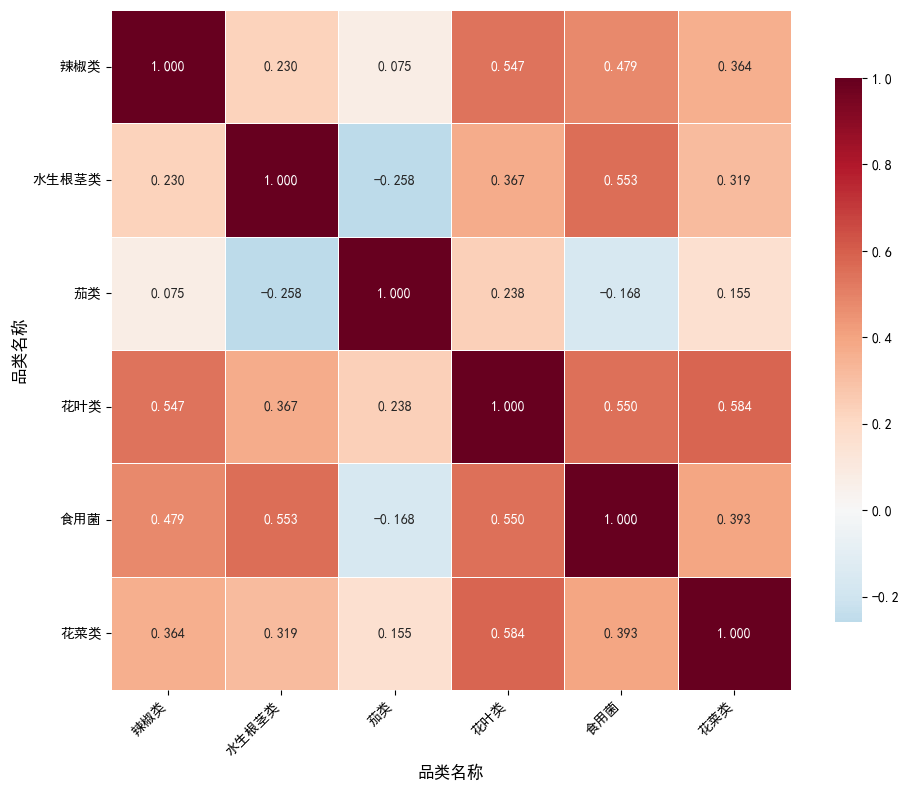


相关性分析：
最强负相关: 水生根茎类 与 茄类 (ρ = -0.258)

相关性强度统计（排除对角线）：
强正相关 (ρ > 0.7): 0 对
中等正相关 (0.3 < ρ ≤ 0.7): 18 对
弱正相关 (0 < ρ ≤ 0.3): 8 对
弱负相关 (-0.3 ≤ ρ < 0): 4 对
中等负相关 (-0.7 ≤ ρ < -0.3): 0 对
强负相关 (ρ < -0.7): 0 对

💡 斯皮尔曼相关系数解读：
• |ρ| > 0.7: 强相关
• 0.3 < |ρ| ≤ 0.7: 中等相关
• |ρ| ≤ 0.3: 弱相关
• ρ > 0: 正相关（同向变化）
• ρ < 0: 负相关（反向变化）
• 斯皮尔曼相关系数衡量变量间的单调关系，不要求线性关系


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 提取各品类的销售量数据（排除日期列）
category_data = daily_sales_cleaned[all_categories]

# 计算斯皮尔曼相关系数矩阵
correlation_matrix = category_data.corr(method='spearman')

print("各品类间斯皮尔曼相关系数矩阵：")
print("=" * 60)
print(correlation_matrix.round(3))

# 创建热图
plt.figure(figsize=(10, 8))

# 使用seaborn绘制热图
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # 创建上三角遮罩（可选）

# 绘制热图
heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,           # 显示数值
    cmap='RdBu_r',        # 色彩映射：红蓝色彩
    center=0,             # 以0为中心
    square=True,          # 正方形单元格
    fmt='.3f',            # 数值格式：保留3位小数
    cbar_kws={'shrink': 0.8},  # 色彩条设置
    linewidths=0.5        # 网格线宽度
)

# 设置标题和标签
# plt.title('各品类日销售量斯皮尔曼相关系数热图', fontsize=16, pad=20)
plt.xlabel('品类名称', fontsize=12)
plt.ylabel('品类名称', fontsize=12)

# 旋转x轴标签避免重叠
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# 分析相关性强度
print("\n相关性分析：")
print("=" * 60)

# 获取相关系数的绝对值，排除对角线
correlation_abs = correlation_matrix.abs()
np.fill_diagonal(correlation_abs.values, 0)  # 将对角线设为0

# 找到最强正相关和负相关
max_corr_idx = np.unravel_index(correlation_matrix.values.argmax(), correlation_matrix.shape)
min_corr_idx = np.unravel_index(correlation_matrix.values.argmin(), correlation_matrix.shape)

if max_corr_idx[0] != max_corr_idx[1]:  # 排除对角线
    max_corr_pair = (correlation_matrix.index[max_corr_idx[0]], 
                     correlation_matrix.columns[max_corr_idx[1]])
    max_corr_value = correlation_matrix.iloc[max_corr_idx]
    print(f"最强正相关: {max_corr_pair[0]} 与 {max_corr_pair[1]} (ρ = {max_corr_value:.3f})")

if min_corr_idx[0] != min_corr_idx[1]:  # 排除对角线
    min_corr_pair = (correlation_matrix.index[min_corr_idx[0]], 
                     correlation_matrix.columns[min_corr_idx[1]])
    min_corr_value = correlation_matrix.iloc[min_corr_idx]
    print(f"最强负相关: {min_corr_pair[0]} 与 {min_corr_pair[1]} (ρ = {min_corr_value:.3f})")

# 统计相关性强度分布
strong_positive = (correlation_matrix > 0.7) & (correlation_matrix < 1.0)
moderate_positive = (correlation_matrix > 0.3) & (correlation_matrix <= 0.7)
weak_positive = (correlation_matrix > 0) & (correlation_matrix <= 0.3)
weak_negative = (correlation_matrix < 0) & (correlation_matrix >= -0.3)
moderate_negative = (correlation_matrix < -0.3) & (correlation_matrix >= -0.7)
strong_negative = correlation_matrix < -0.7

print(f"\n相关性强度统计（排除对角线）：")
print(f"强正相关 (ρ > 0.7): {strong_positive.sum().sum()} 对")
print(f"中等正相关 (0.3 < ρ ≤ 0.7): {moderate_positive.sum().sum()} 对")
print(f"弱正相关 (0 < ρ ≤ 0.3): {weak_positive.sum().sum()} 对")
print(f"弱负相关 (-0.3 ≤ ρ < 0): {weak_negative.sum().sum()} 对")
print(f"中等负相关 (-0.7 ≤ ρ < -0.3): {moderate_negative.sum().sum()} 对")
print(f"强负相关 (ρ < -0.7): {strong_negative.sum().sum()} 对")

print(f"\n💡 斯皮尔曼相关系数解读：")
print(f"• |ρ| > 0.7: 强相关")
print(f"• 0.3 < |ρ| ≤ 0.7: 中等相关") 
print(f"• |ρ| ≤ 0.3: 弱相关")
print(f"• ρ > 0: 正相关（同向变化）")
print(f"• ρ < 0: 负相关（反向变化）")
print(f"• 斯皮尔曼相关系数衡量变量间的单调关系，不要求线性关系")

d:\python3.11.9\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Prophet时间序列建模和预测分析

【辣椒类】Prophet建模:
----------------------------------------


15:18:18 - cmdstanpy - INFO - Chain [1] start processing
15:18:19 - cmdstanpy - INFO - Chain [1] done processing
15:18:19 - cmdstanpy - INFO - Chain [1] start processing


  ✅ 建模成功，数据点: 961
  历史趋势: 历史上升 (变化: +38.90)
  未来趋势: 预测上升 (变化: +0.96)
  预测范围: 77.69 ~ 147.08
  模型精度: MAE=16.90, MAPE=27.6%

【水生根茎类】Prophet建模:
----------------------------------------


15:18:19 - cmdstanpy - INFO - Chain [1] done processing
15:18:19 - cmdstanpy - INFO - Chain [1] start processing


...

  ✅ 建模成功，数据点: 961
  历史趋势: 历史上升 (变化: +10.21)
  未来趋势: 预测下降 (变化: -2.08)
  预测范围: 154.08 ~ 285.07
  模型精度: MAE=30.05, MAPE=20.8%

【食用菌】Prophet建模:
----------------------------------------


15:18:21 - cmdstanpy - INFO - Chain [1] done processing
15:18:21 - cmdstanpy - INFO - Chain [1] start processing


  ✅ 建模成功，数据点: 961
  历史趋势: 历史上升 (变化: +29.20)
  未来趋势: 预测上升 (变化: +2.93)
  预测范围: 64.75 ~ 111.90
  模型精度: MAE=14.27, MAPE=31.7%

【花菜类】Prophet建模:
----------------------------------------


15:18:21 - cmdstanpy - INFO - Chain [1] done processing


  ✅ 建模成功，数据点: 961
  历史趋势: 历史下降 (变化: -18.81)
  未来趋势: 预测下降 (变化: -0.99)
  预测范围: 27.48 ~ 50.92
  模型精度: MAE=10.20, MAPE=2362.8%

Prophet预测结果可视化


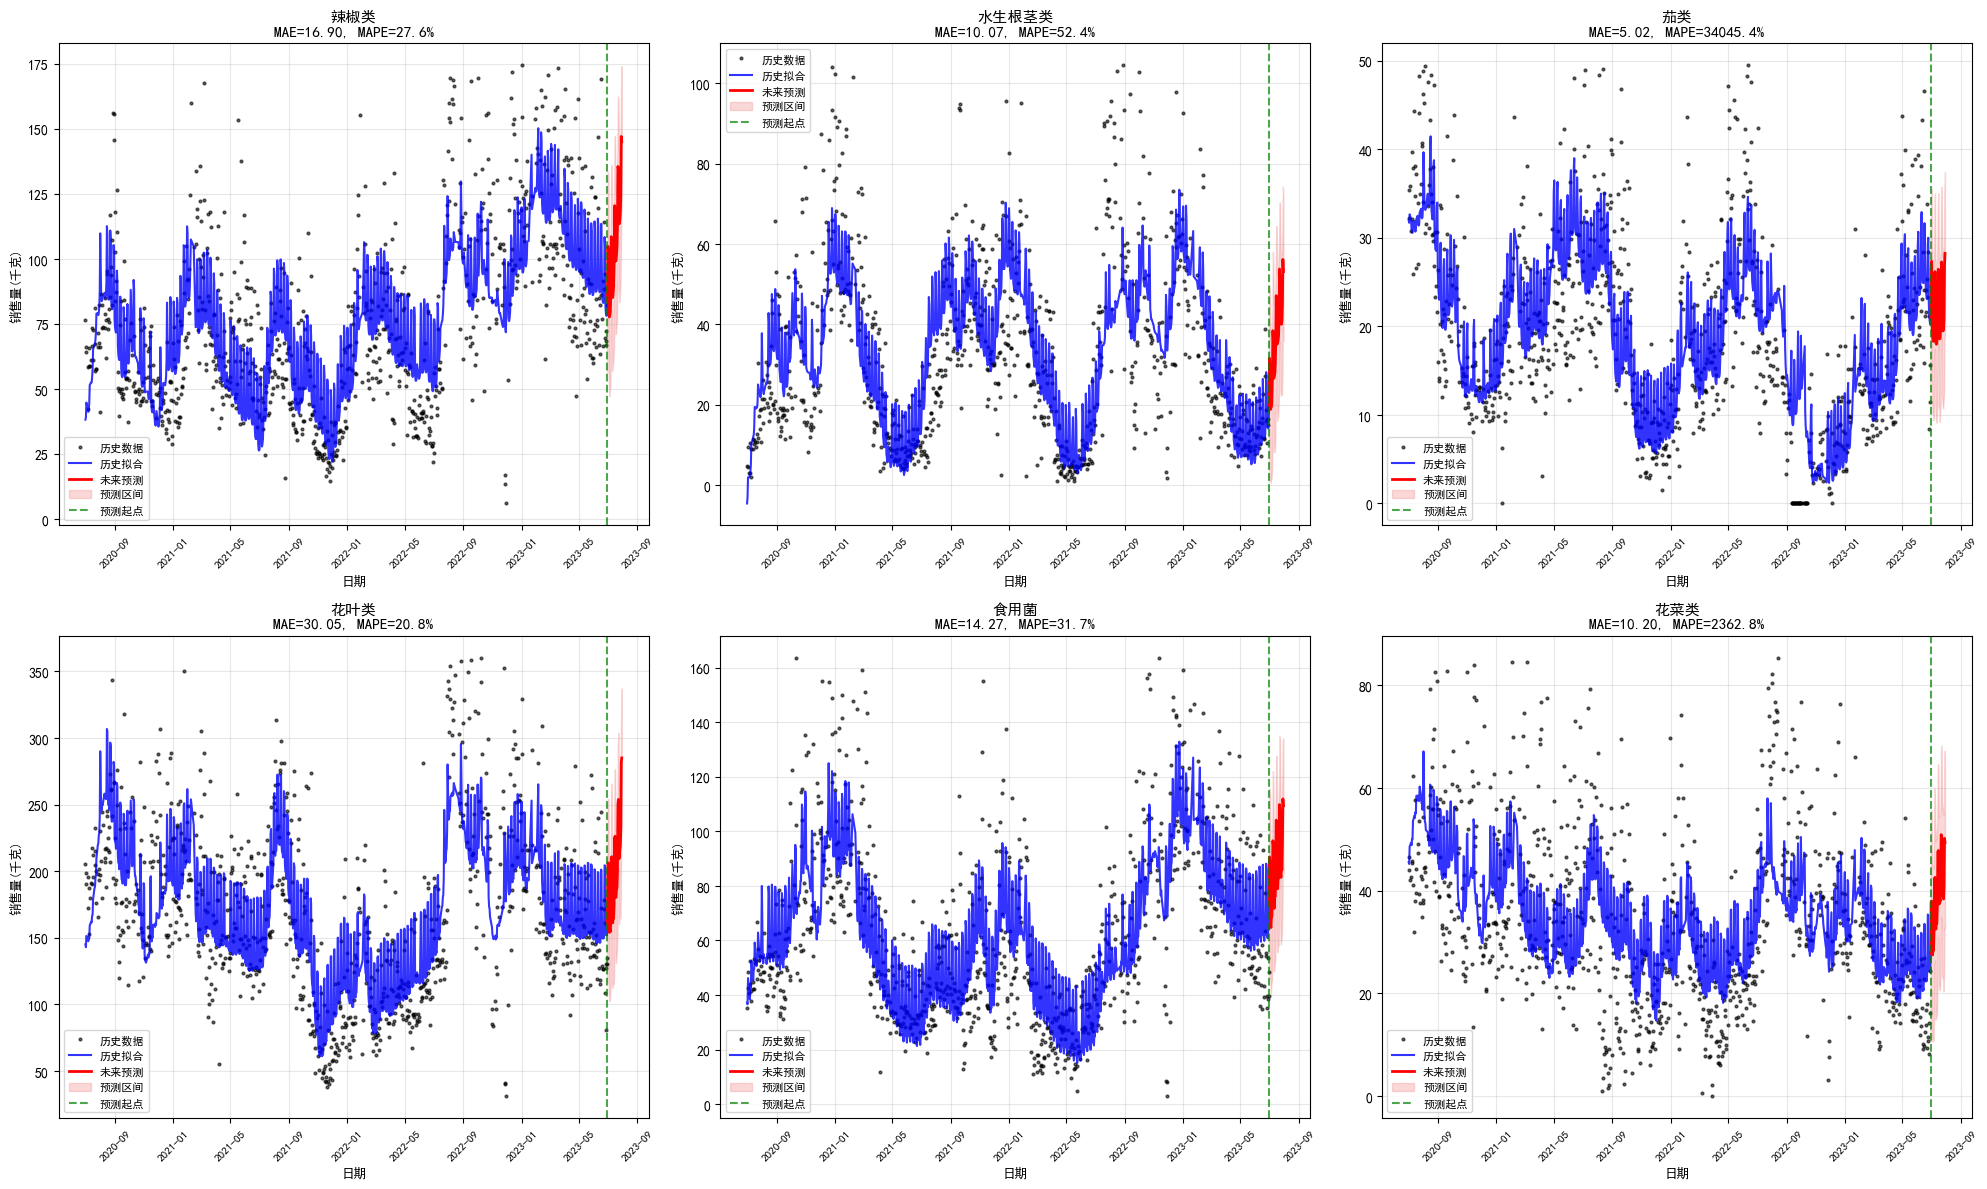


Prophet组件分解图（6个品类）:
--------------------------------------------------


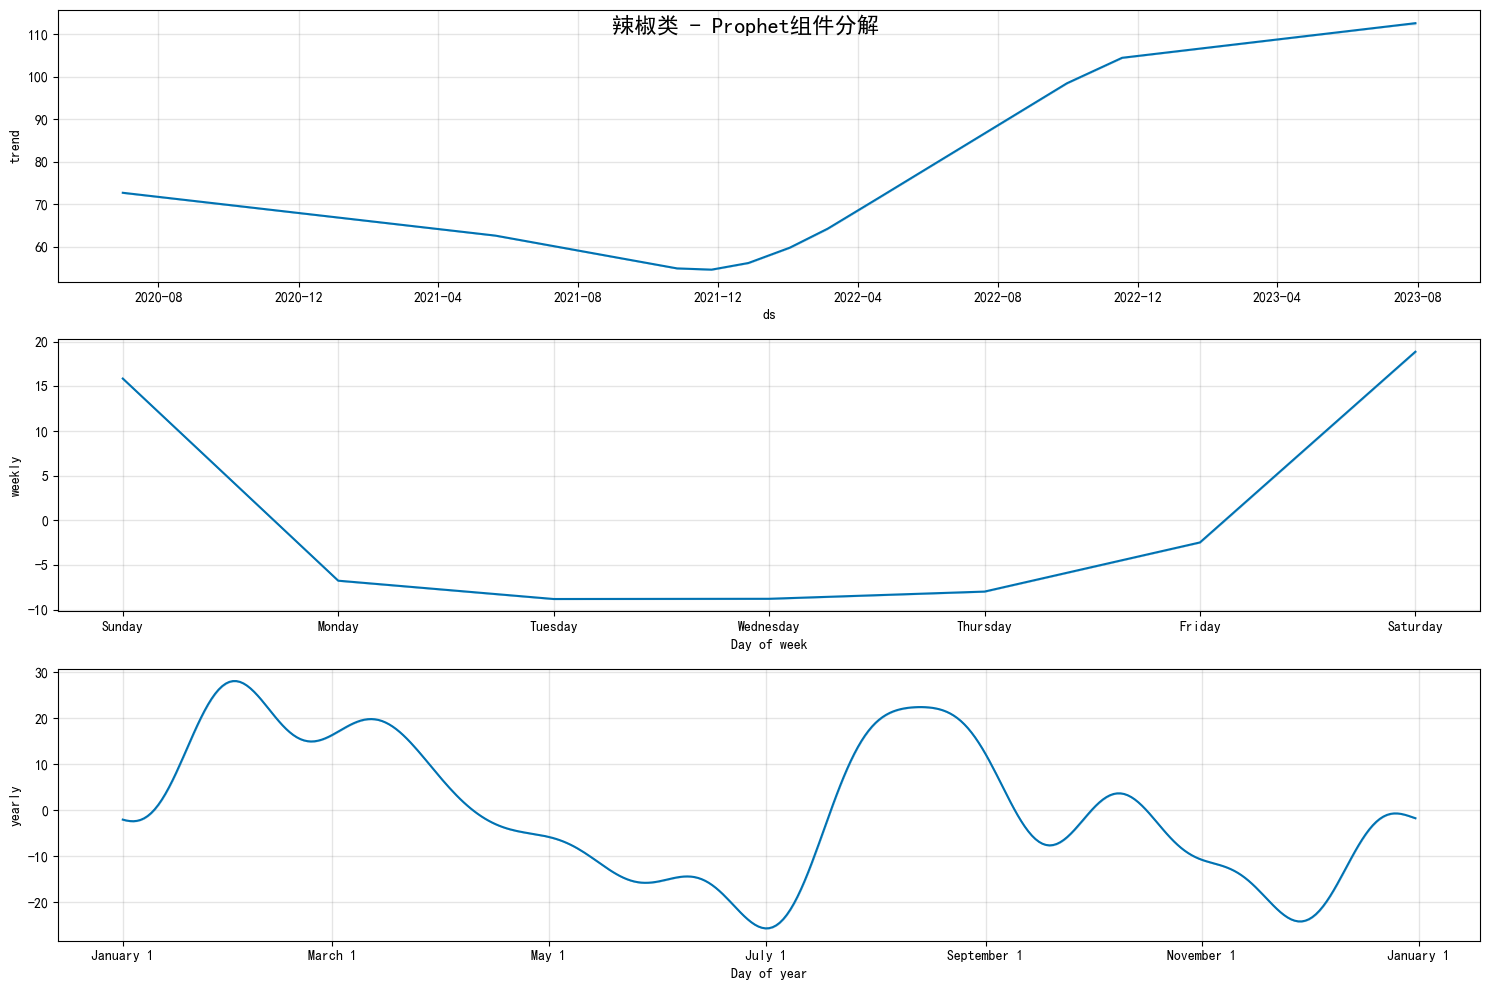

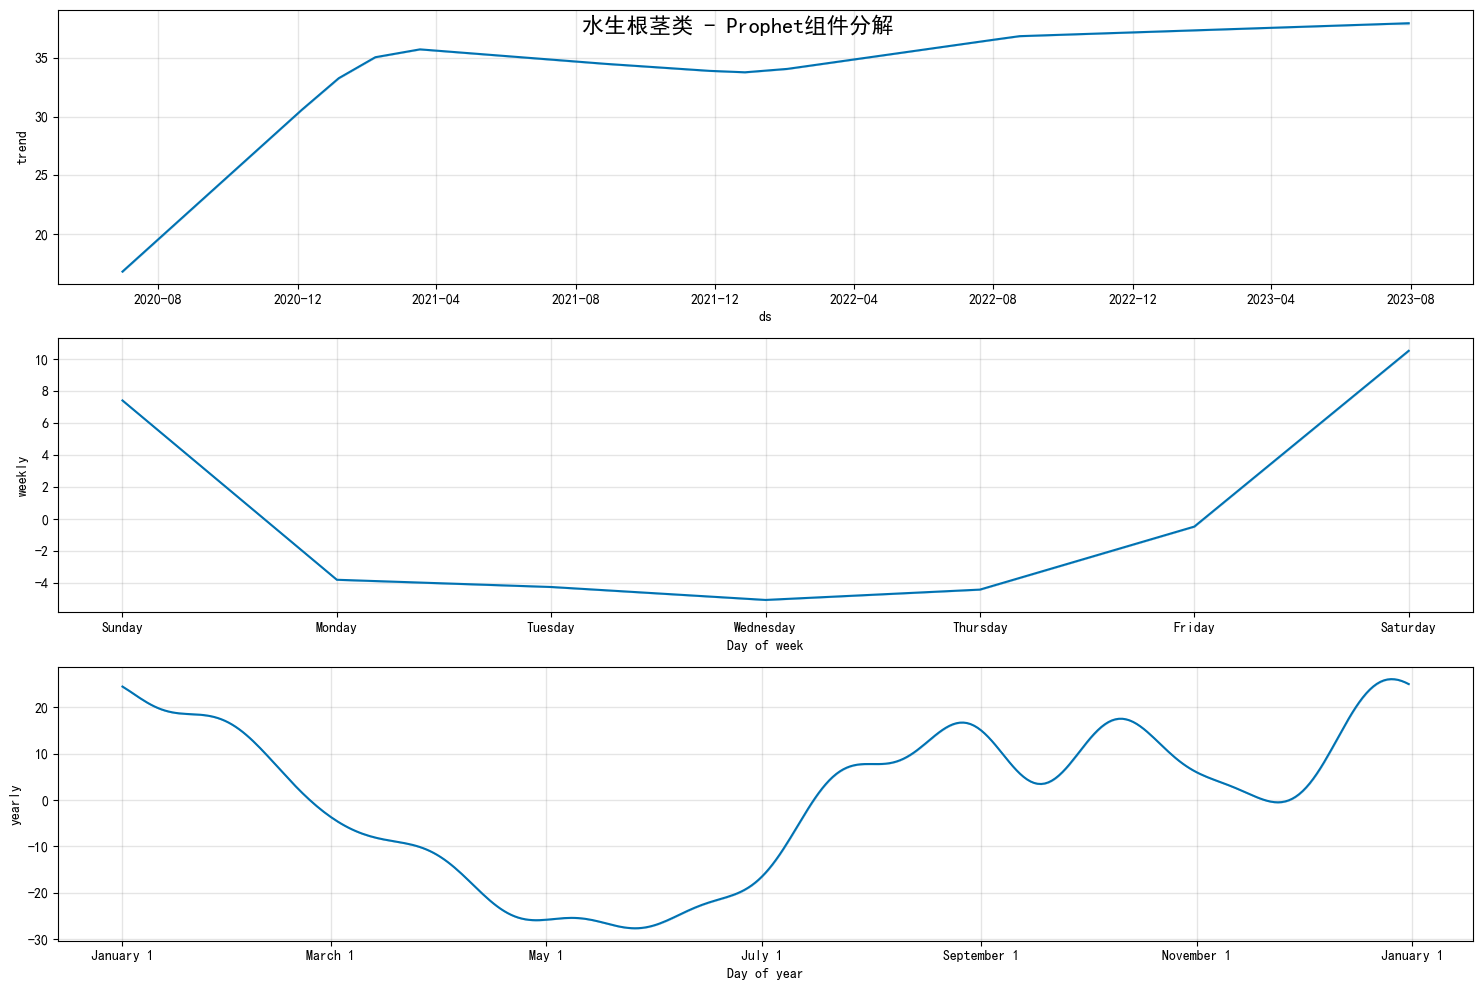

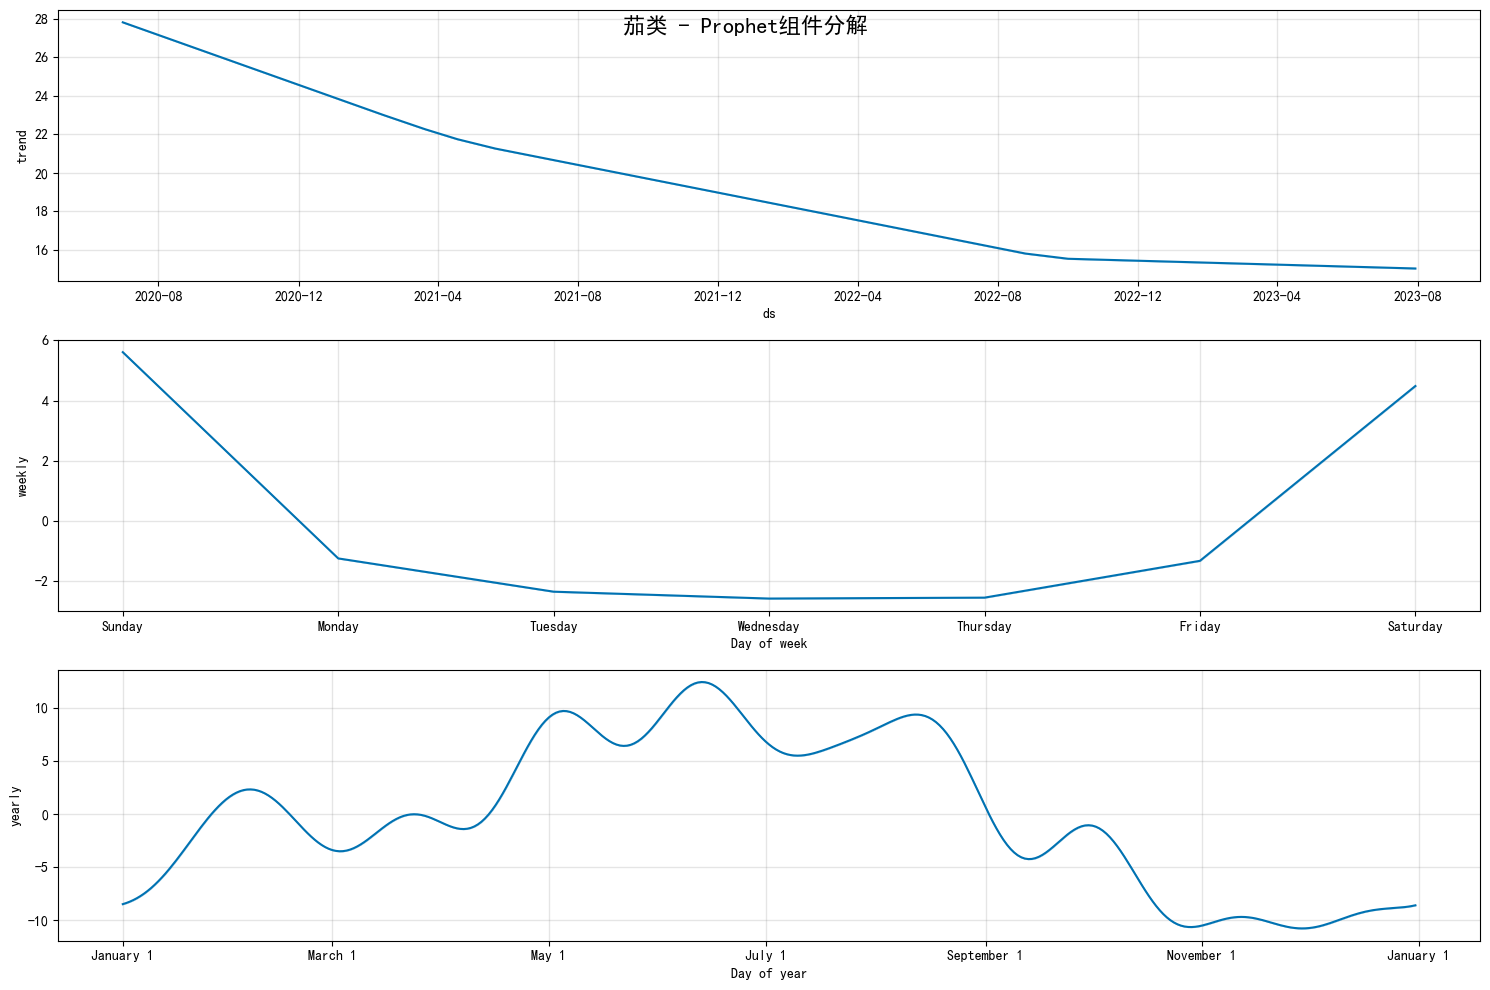

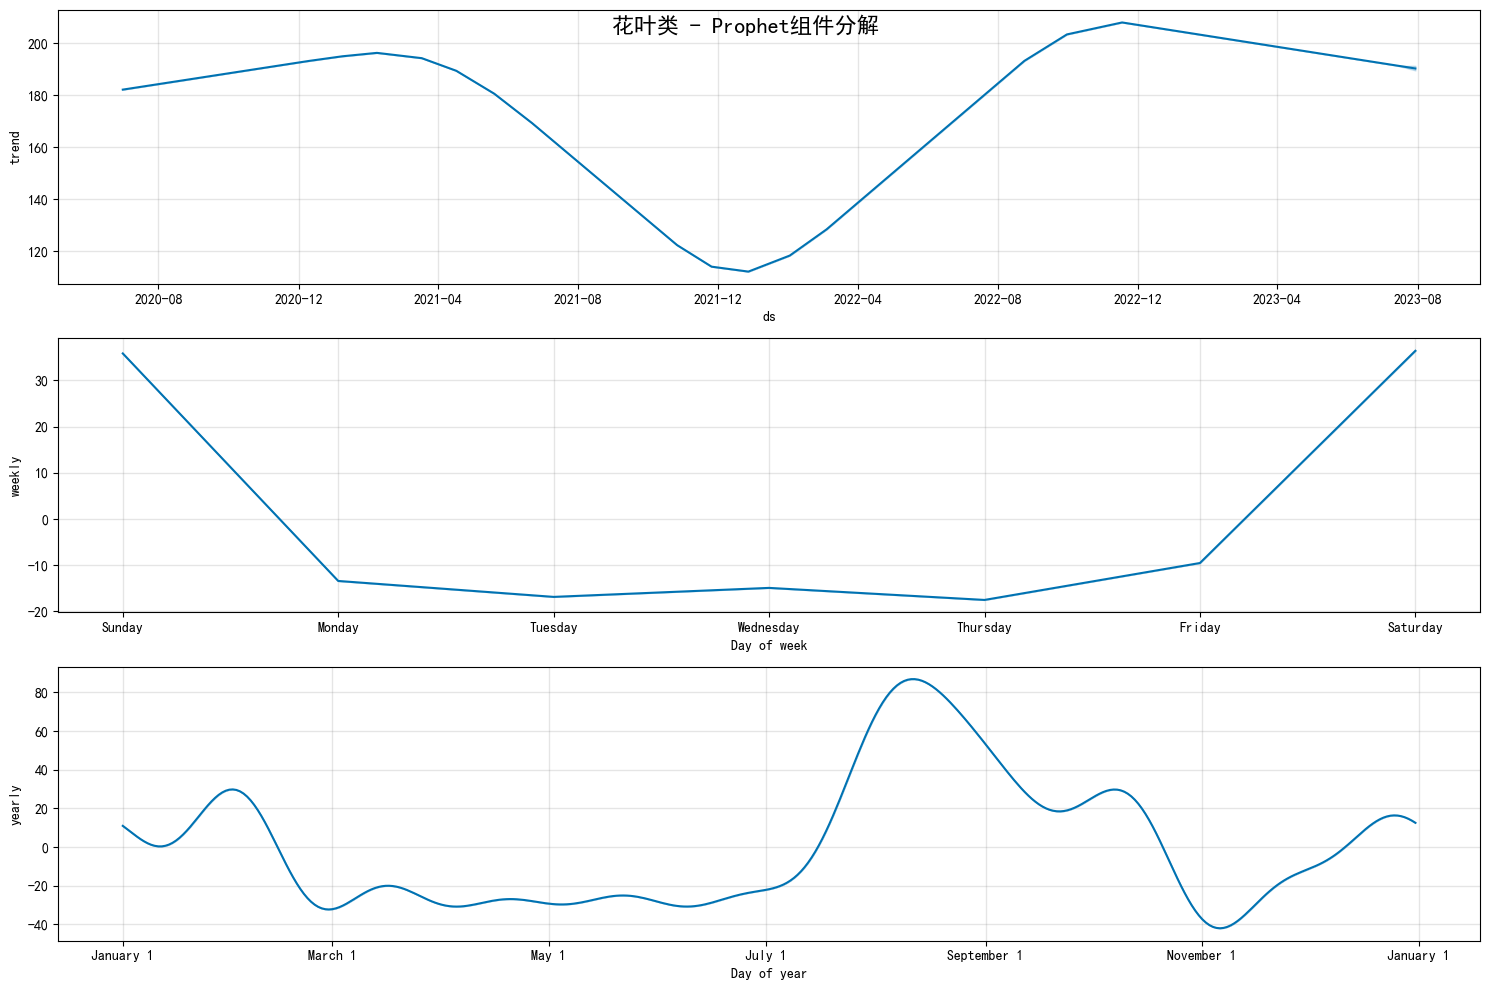

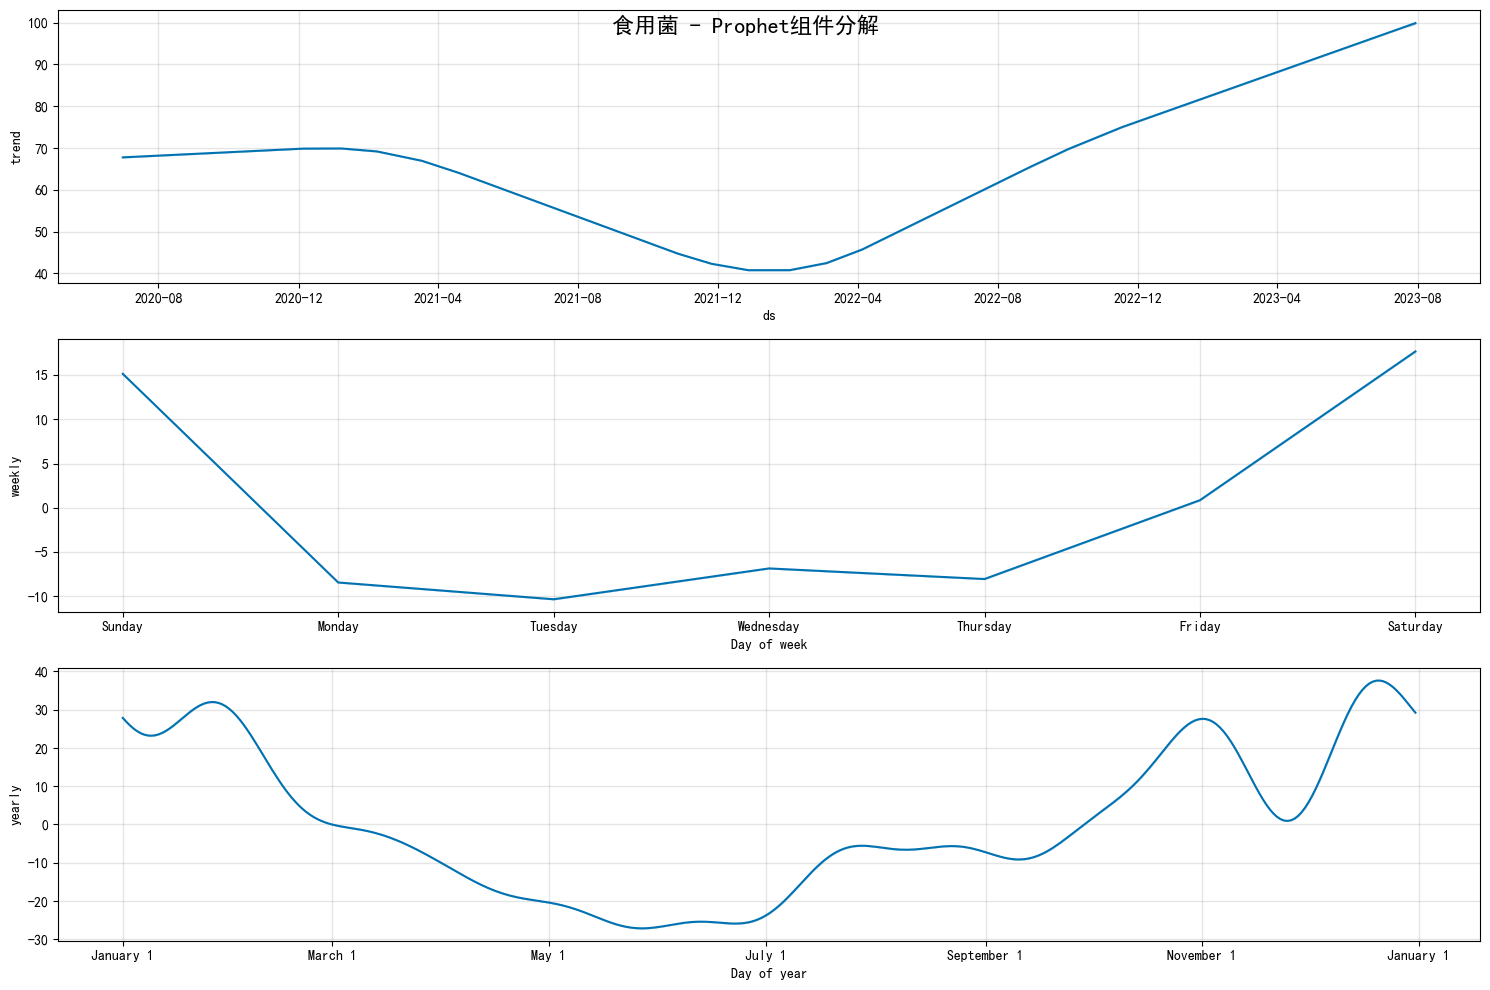

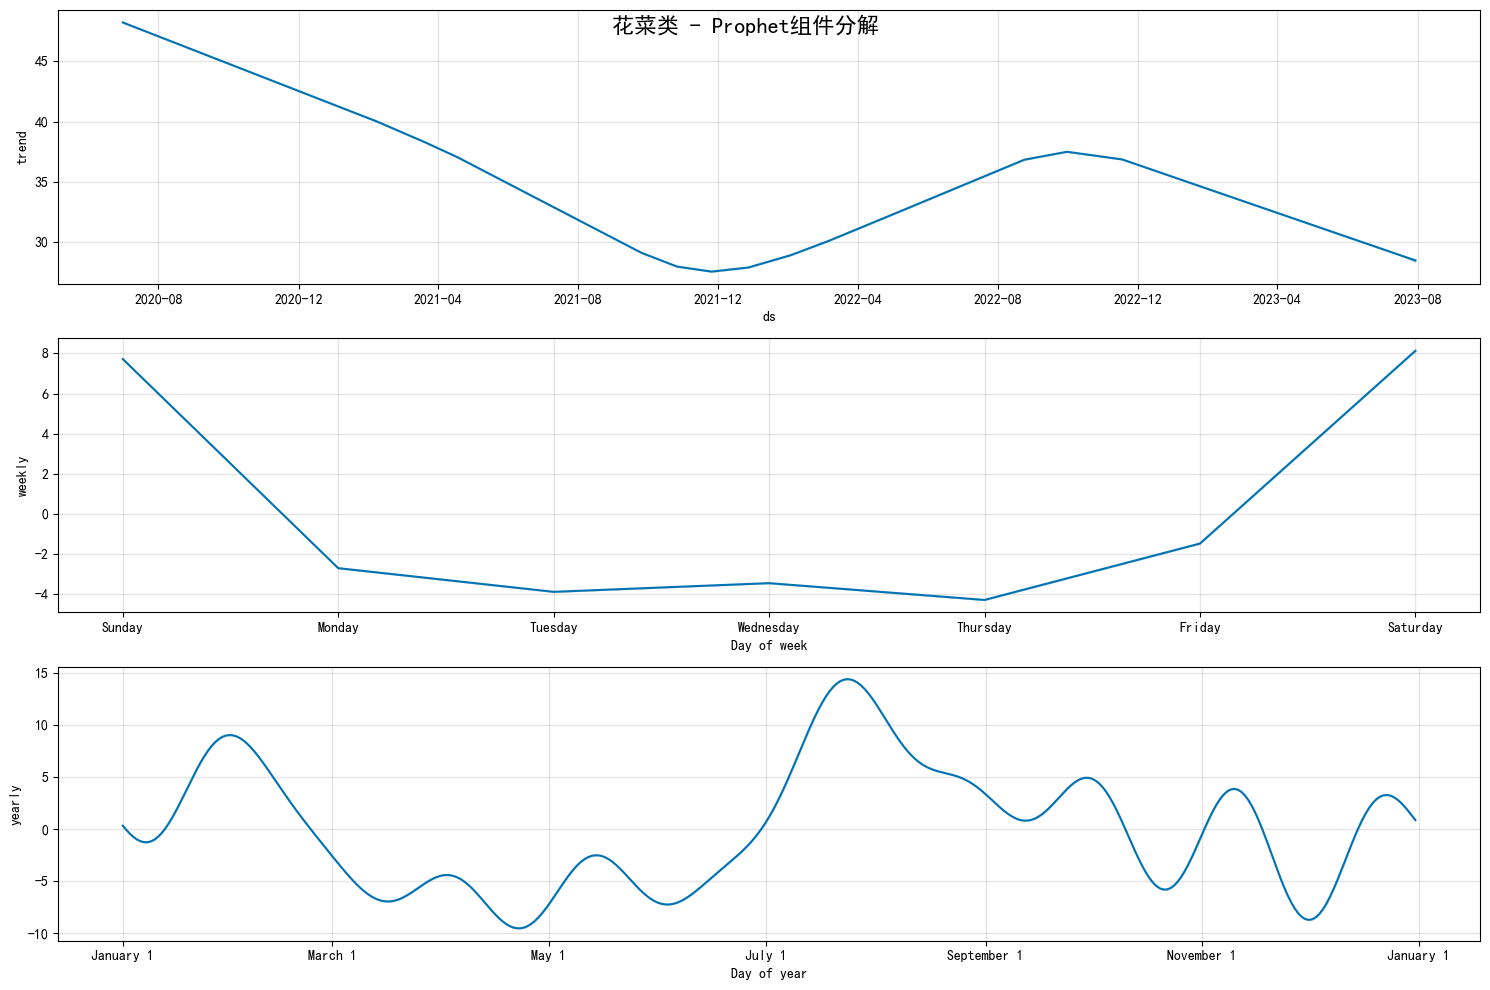


📊 Prophet模型性能总结:
--------------------------------------------------------------------------------
品类           MAE      MAPE(%)    模型质量      
--------------------------------------------------
花叶类          30.05    20.8       良好        
辣椒类          16.90    27.6       良好        
食用菌          14.27    31.7       良好        
水生根茎类        10.07    52.4       一般        
花菜类          10.20    2362.8     较差        
茄类           5.02     34045.4    较差        

平均性能: MAE=14.42, MAPE=6090.1%

🎯 Prophet模型分析总结:
----------------------------------------------------------------------
成功建模品类数: 6/6
预测时间范围: 未来30天
模型特点:
  • 自动处理节假日效应和季节性
  • 自动检测趋势变化点
  • 提供预测置信区间
  • 处理缺失值和零值
  • 分解趋势、季节性、节假日效应

✅ Prophet分析完成！
📊 分解结果存储在 decomposition_results 字典中（基于Prophet）
   包含: 'original', 'trend', 'seasonal', 'residual' 四个分量
🔮 预测结果存储在 prophet_results 字典中


In [13]:
# Prophet时间序列建模和预测分析
try:
    from prophet import Prophet
    import warnings
    warnings.filterwarnings('ignore')
    
    print("Prophet时间序列建模和预测分析")
    print("=" * 80)
    
    # 准备时间序列数据
    ts_data = daily_sales_cleaned.copy()
    ts_data['日期'] = pd.to_datetime(ts_data['日期'])
    ts_data = ts_data.set_index('日期').sort_index()
    
    # 存储Prophet模型结果
    prophet_results = {}
    
    # 为每个品类建立Prophet模型
    for category in all_categories:
        if category in ts_data.columns:
            print(f"\n【{category}】Prophet建模:")
            print("-" * 40)
            
            # 准备Prophet数据格式
            prophet_data = pd.DataFrame({
                'ds': ts_data.index,  # 日期列必须命名为'ds'
                'y': ts_data[category].values  # 目标变量必须命名为'y'
            })
            
            # 保留所有数据点（包括0值，Prophet可以处理）
            prophet_data = prophet_data.reset_index(drop=True)
            
            if len(prophet_data) < 10:
                print(f"  数据点太少，跳过Prophet建模")
                continue
            
            try:
                # 创建Prophet模型
                model = Prophet(
                    yearly_seasonality=True,       # 年度季节性
                    weekly_seasonality=True,       # 周度季节性
                    daily_seasonality=False,       # 日度季节性（关闭）
                    seasonality_mode='additive',   # 加法季节性模式
                    changepoint_prior_scale=0.05,  # 趋势变化点敏感度
                    seasonality_prior_scale=10,    # 季节性先验尺度
                    holidays_prior_scale=10,       # 节假日先验尺度
                    mcmc_samples=0,                # MCMC采样数（0表示使用MAP估计）
                    interval_width=0.8,            # 预测区间宽度
                    uncertainty_samples=1000       # 不确定性采样数
                )
                
                # 训练模型
                model.fit(prophet_data)
                
                # 创建未来日期框架（预测30天）
                future = model.make_future_dataframe(periods=30)
                
                # 进行预测
                forecast = model.predict(future)
                
                # 计算模型评估指标
                # 使用历史数据计算MAE和MAPE
                historical_forecast = forecast.iloc[:len(prophet_data)]
                actual_values = prophet_data['y'].values
                predicted_values = historical_forecast['yhat'].values
                
                mae = np.mean(np.abs(actual_values - predicted_values))
                mape = np.mean(np.abs((actual_values - predicted_values) / (actual_values + 0.001))) * 100
                
                # 存储结果
                prophet_results[category] = {
                    'model': model,
                    'data': prophet_data,
                    'forecast': forecast,
                    'future': future,
                    'mae': mae,
                    'mape': mape
                }
                
                print(f"  ✅ 建模成功，数据点: {len(prophet_data)}")
                
                # 分析趋势方向
                trend_start = forecast['trend'].iloc[0]
                trend_end = forecast['trend'].iloc[-31]  # 历史数据的最后一个点
                trend_future = forecast['trend'].iloc[-1]  # 预测的最后一个点
                
                trend_change = trend_end - trend_start
                future_trend_change = trend_future - trend_end
                
                if trend_change > 0:
                    trend_direction = "历史上升"
                elif trend_change < 0:
                    trend_direction = "历史下降"
                else:
                    trend_direction = "历史平稳"
                
                if future_trend_change > 0:
                    future_direction = "预测上升"
                elif future_trend_change < 0:
                    future_direction = "预测下降"
                else:
                    future_direction = "预测平稳"
                
                print(f"  历史趋势: {trend_direction} (变化: {trend_change:+.2f})")
                print(f"  未来趋势: {future_direction} (变化: {future_trend_change:+.2f})")
                print(f"  预测范围: {forecast['yhat'].iloc[-30:].min():.2f} ~ {forecast['yhat'].iloc[-30:].max():.2f}")
                print(f"  模型精度: MAE={mae:.2f}, MAPE={mape:.1f}%")
                
            except Exception as e:
                print(f"  ❌ 建模失败: {str(e)}")
                continue
    
    # 绘制Prophet预测结果
    print(f"\n" + "="*80)
    print("Prophet预测结果可视化")
    print("="*80)
    
    # 选择所有成功建模的品类进行可视化
    successful_categories = list(prophet_results.keys())
    
    if successful_categories:
        # 计算布局
        n_categories = len(successful_categories)
        cols = 3
        rows = (n_categories + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(20, 6*rows))
        if rows == 1:
            axes = axes.reshape(1, -1) if n_categories > 1 else [axes]
        
        for idx, category in enumerate(successful_categories):
            row = idx // cols
            col = idx % cols
            ax = axes[row, col] if rows > 1 else axes[col]
            
            result = prophet_results[category]
            forecast = result['forecast']
            data = result['data']
            
            # 分割历史和预测数据
            historical_forecast = forecast.iloc[:len(data)]
            future_forecast = forecast.iloc[len(data)-1:]  # 包含最后一个历史点用于连接
            
            # 绘制历史数据
            ax.plot(data['ds'], data['y'], 
                   'ko', markersize=2, alpha=0.6, label='历史数据')
            
            # 绘制历史拟合
            ax.plot(historical_forecast['ds'], historical_forecast['yhat'], 
                   'b-', linewidth=1.5, alpha=0.8, label='历史拟合')
            
            # 绘制未来预测
            ax.plot(future_forecast['ds'], future_forecast['yhat'], 
                   'r-', linewidth=2, label='未来预测')
            
            # 绘制预测置信区间
            ax.fill_between(future_forecast['ds'], 
                           future_forecast['yhat_lower'], 
                           future_forecast['yhat_upper'],
                           alpha=0.3, color='lightcoral', label='预测区间')
            
            # 分割线（历史vs预测）
            split_date = data['ds'].iloc[-1]
            ax.axvline(x=split_date, color='green', linestyle='--', alpha=0.7, label='预测起点')
            
            ax.set_title(f'{category}\nMAE={result["mae"]:.2f}, MAPE={result["mape"]:.1f}%', fontsize=11)
            ax.set_xlabel('日期', fontsize=9)
            ax.set_ylabel('销售量(千克)', fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # 旋转x轴标签
            ax.tick_params(axis='x', rotation=45, labelsize=8)
        
        # 隐藏多余子图
        for idx in range(n_categories, rows * cols):
            row = idx // cols
            col = idx % cols
            if rows > 1:
                axes[row, col].set_visible(False)
            else:
                axes[col].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        
        # 绘制Prophet组件分解（6个品类详细展示）
        print(f"\nProphet组件分解图（6个品类）:")
        print("-" * 50)
        
        for category in successful_categories[:6]:
            result = prophet_results[category]
            
            # 使用Prophet内置的plot_components方法
            fig = result['model'].plot_components(result['forecast'], figsize=(15, 10))
            fig.suptitle(f'{category} - Prophet组件分解', fontsize=16)
            plt.show()
        
        # Prophet模型性能总结
        print(f"\n📊 Prophet模型性能总结:")
        print("-" * 80)
        
        performance_data = []
        for category, result in prophet_results.items():
            performance_data.append({
                'category': category,
                'mae': result['mae'],
                'mape': result['mape']
            })
        
        # 按MAPE排序显示
        performance_data.sort(key=lambda x: x['mape'])
        
        print(f"{'品类':<12} {'MAE':<8} {'MAPE(%)':<10} {'模型质量':<10}")
        print("-" * 50)
        
        for item in performance_data:
            if item['mape'] < 20:
                quality = "优秀"
            elif item['mape'] < 50:
                quality = "良好" 
            elif item['mape'] < 100:
                quality = "一般"
            else:
                quality = "较差"
            
            print(f"{item['category']:<12} {item['mae']:<8.2f} {item['mape']:<10.1f} {quality:<10}")
        
        avg_mae = np.mean([item['mae'] for item in performance_data])
        avg_mape = np.mean([item['mape'] for item in performance_data])
        
        print(f"\n平均性能: MAE={avg_mae:.2f}, MAPE={avg_mape:.1f}%")
    
    # Prophet模型分析总结
    print(f"\n🎯 Prophet模型分析总结:")
    print("-" * 70)
    print(f"成功建模品类数: {len(prophet_results)}/{len(all_categories)}")
    print(f"预测时间范围: 未来30天")
    print(f"模型特点:")
    print(f"  • 自动处理节假日效应和季节性")
    print(f"  • 自动检测趋势变化点")
    print(f"  • 提供预测置信区间")
    print(f"  • 处理缺失值和零值")
    print(f"  • 分解趋势、季节性、节假日效应")
    
    # 存储Prophet趋势数据用于后续分布分析
    decomposition_results = {}
    for category, result in prophet_results.items():
        forecast = result['forecast']
        historical_forecast = forecast.iloc[:len(result['data'])]
        
        decomposition_results[category] = {
            'original': pd.Series(result['data']['y'].values, index=result['data']['ds']),
            'trend': pd.Series(historical_forecast['trend'].values, index=historical_forecast['ds']),
            'seasonal': pd.Series(historical_forecast['weekly'].values + historical_forecast['yearly'].values, 
                                index=historical_forecast['ds']),
            'residual': pd.Series(result['data']['y'].values - historical_forecast['yhat'].values, 
                                index=historical_forecast['ds'])
        }
    
    print(f"\n✅ Prophet分析完成！")
    print(f"📊 分解结果存储在 decomposition_results 字典中（基于Prophet）")
    print(f"   包含: 'original', 'trend', 'seasonal', 'residual' 四个分量")
    print(f"🔮 预测结果存储在 prophet_results 字典中")

except ImportError:
    print("=" * 80)
    print("❌ 未安装Prophet库")
    print("=" * 80)
    print("请安装Prophet库以使用时间序列预测功能：")
    print("  方法1: pip install prophet")
    print("  方法2: conda install -c conda-forge prophet")
    print("  方法3: pip install pystan prophet（如果方法1失败）")
    print("")
    print("安装后重新运行此单元格即可使用Prophet功能")
    print("=" * 80)
    
    # 使用传统方法作为备选方案
    print("\n使用传统时间序列分解作为备选方案...")
    from statsmodels.tsa.seasonal import seasonal_decompose
    
    # 准备时间序列数据
    ts_data = daily_sales_cleaned.copy()
    ts_data['日期'] = pd.to_datetime(ts_data['日期'])
    ts_data = ts_data.set_index('日期').sort_index()
    
    # 存储分解结果
    decomposition_results = {}
    
    print("各品类传统时间序列分解结果：")
    print("-" * 80)
    
    for category in all_categories:
        if category in ts_data.columns:
            print(f"\n【{category}】时间序列分解:")
            
            ts = ts_data[category]
            
            try:
                decomposition = seasonal_decompose(
                    ts, 
                    model='additive',
                    period=30,
                    extrapolate_trend='freq'
                )
                
                decomposition_results[category] = {
                    'original': ts,
                    'trend': decomposition.trend,
                    'seasonal': decomposition.seasonal,
                    'residual': decomposition.resid
                }
                
                trend_mean = decomposition.trend.mean()
                trend_start = decomposition.trend.dropna().iloc[0]
                trend_end = decomposition.trend.dropna().iloc[-1]
                trend_change = trend_end - trend_start
                
                if trend_change > trend_mean * 0.1:
                    trend_direction = "上升趋势"
                elif trend_change < -trend_mean * 0.1:
                    trend_direction = "下降趋势"
                else:
                    trend_direction = "平稳趋势"
                
                print(f"  趋势分量平均值: {trend_mean:.2f}")
                print(f"  总体趋势: {trend_direction} (变化: {trend_change:+.2f})")
                
            except Exception as e:
                print(f"  分解失败: {str(e)}")
                continue
    
    print(f"\n✅ 传统时间序列分解完成！")

except Exception as e:
    print(f"Prophet分析过程中出现错误: {str(e)}")
    print("正在使用传统分解方法...")
    
    # 使用传统方法作为备选
    from statsmodels.tsa.seasonal import seasonal_decompose
    
    ts_data = daily_sales_cleaned.copy()
    ts_data['日期'] = pd.to_datetime(ts_data['日期'])
    ts_data = ts_data.set_index('日期').sort_index()
    
    decomposition_results = {}
    
    for category in all_categories:
        if category in ts_data.columns:
            try:
                ts = ts_data[category]
                decomposition = seasonal_decompose(ts, model='additive', period=30, extrapolate_trend='freq')
                decomposition_results[category] = {
                    'original': ts,
                    'trend': decomposition.trend,
                    'seasonal': decomposition.seasonal,
                    'residual': decomposition.resid
                }
            except:
                continue

基于时间序列趋势分量的分布拟合检验
🔄 使用传统时间序列分解方法处理特定品类:
------------------------------------------------------------

【茄类】传统时间序列分解:
  ✅ 传统分解成功
  趋势分量平均值: 19.35
  总体趋势: 下降趋势 (变化: -18.04)
  趋势变异系数: 0.4401

【花叶类】传统时间序列分解:
  ✅ 传统分解成功
  趋势分量平均值: 168.67
  总体趋势: 下降趋势 (变化: -32.22)
  趋势变异系数: 0.2725
✅ 辣椒类: 使用Prophet时间序列分解
✅ 水生根茎类: 使用Prophet时间序列分解
✅ 茄类: 使用传统时间序列分解
✅ 花叶类: 使用传统时间序列分解
✅ 食用菌: 使用Prophet时间序列分解
✅ 花菜类: 使用Prophet时间序列分解

开始分布拟合分析:
------------------------------------------------------------

【辣椒类】趋势分量分布检验结果:
--------------------------------------------------
  有效趋势数据点: 961
  趋势范围: [54.63, 111.59]
  正态分布        : KS=0.2092, p=0.0000, AIC=8412.07, R²=0.8703
  对数正态分布      : KS=0.0998, p=0.0000, AIC=7998.94, R²=0.9800
  指数分布        : KS=0.1014, p=0.0000, AIC=7860.19, R²=0.9786
  伽马分布        : KS=0.0999, p=0.0000, AIC=7854.05, R²=0.9776
  Weibull分布   : KS=0.0988, p=0.0000, AIC=7861.26, R²=0.9793
  贝塔分布        : KS=0.2870, p=0.0000, AIC=-11.95, R²=0.7200
  卡方分布        : KS=0.1063, p=0.0000, AIC=7856.71, R²=0.97

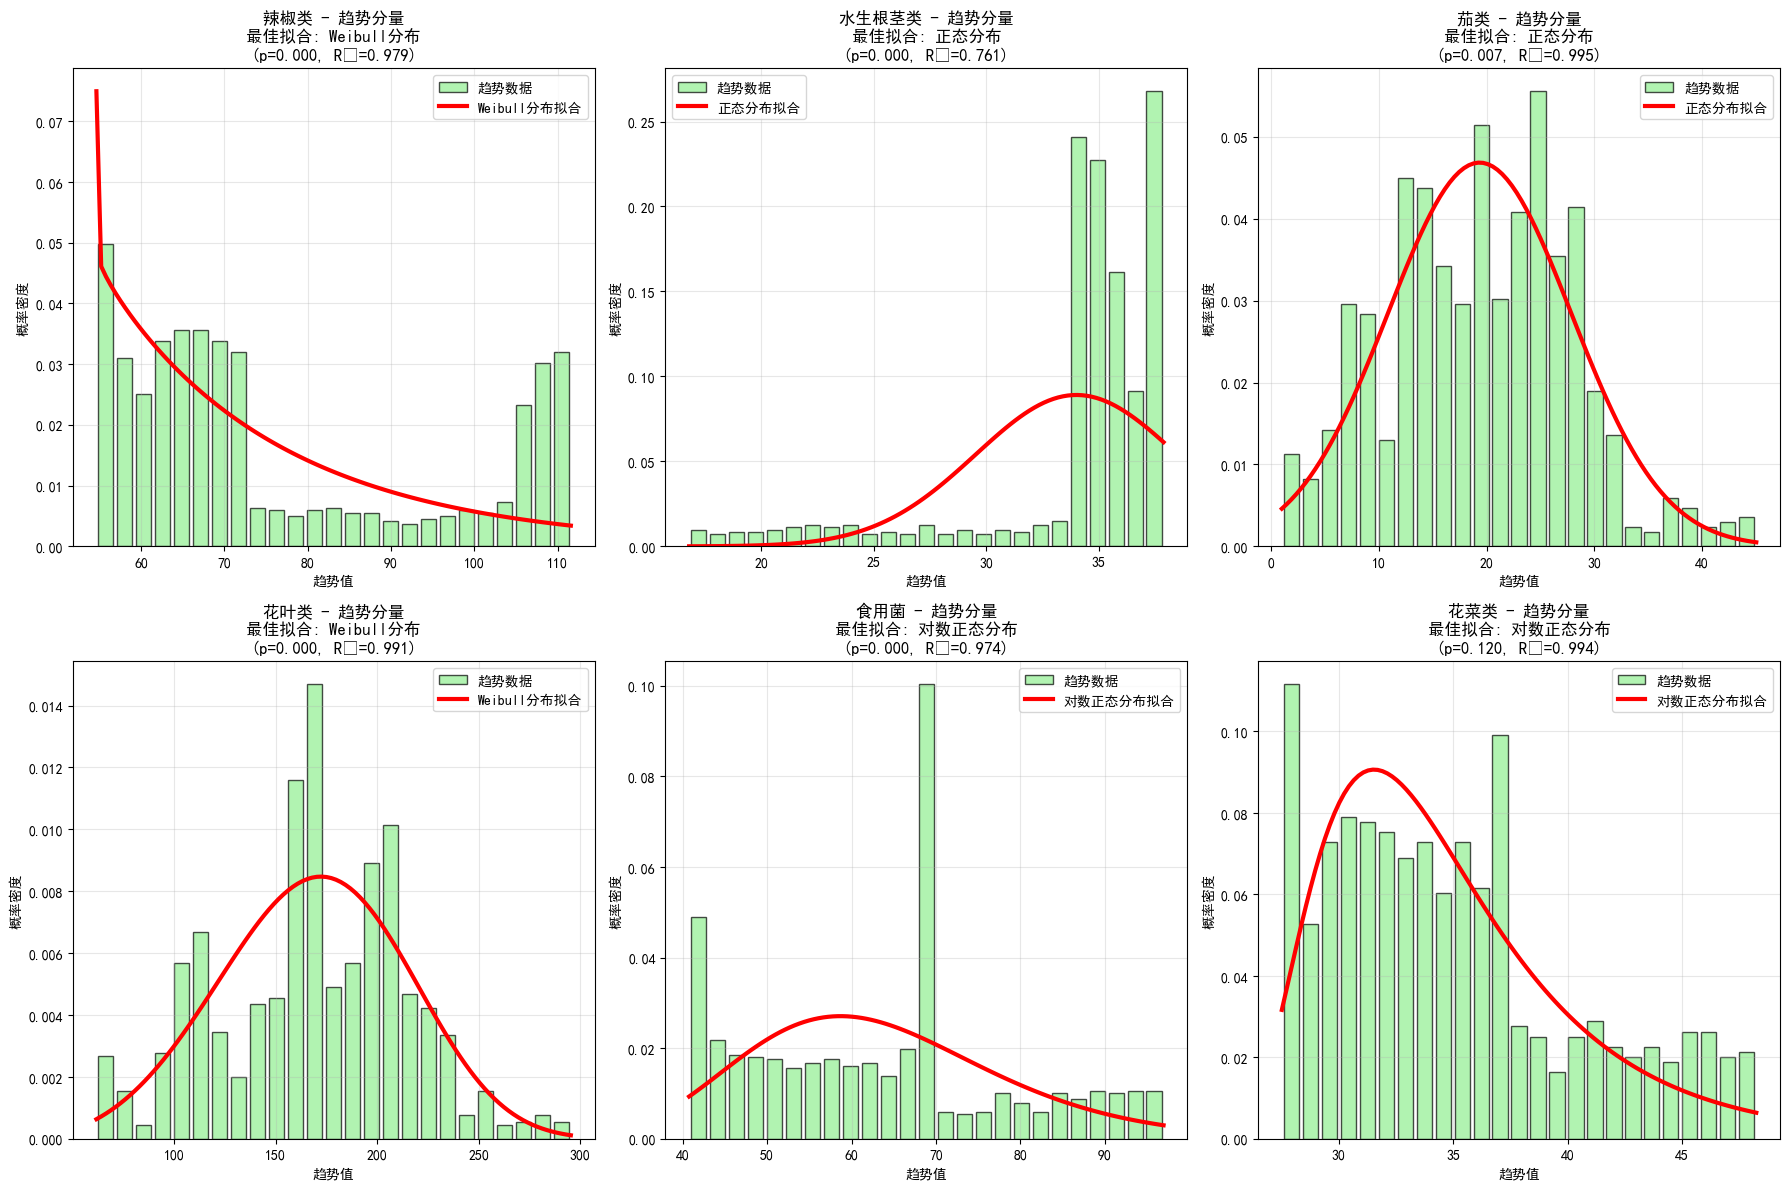


📊 趋势分量vs原始数据分布对比:
--------------------------------------------------------------------------------

辣椒类:
  原始数据: 均值=75.05, 标准差=34.04
  趋势分量: 均值=76.55, 标准差=19.22
  最佳拟合分布: Weibull分布
  拟合质量: p值=0.0000, R²=0.9793

水生根茎类:
  原始数据: 均值=32.48, 标准差=22.15
  趋势分量: 均值=34.00, 标准差=4.48
  最佳拟合分布: 正态分布
  拟合质量: p值=0.0000, R²=0.7605

茄类:
  原始数据: 均值=19.78, 标准差=10.29
  趋势分量: 均值=19.35, 标准差=8.51
  最佳拟合分布: 正态分布
  拟合质量: p值=0.0071, R²=0.9948

花叶类:
  原始数据: 均值=168.48, 标准差=64.09
  趋势分量: 均值=168.67, 标准差=45.95
  最佳拟合分布: Weibull分布
  拟合质量: p值=0.0001, R²=0.9910

食用菌:
  原始数据: 均值=61.50, 标准差=31.88
  趋势分量: 均值=63.58, 标准差=15.32
  最佳拟合分布: 对数正态分布
  拟合质量: p值=0.0000, R²=0.9737

花菜类:
  原始数据: 均值=34.16, 标准差=16.97
  趋势分量: 均值=34.98, 标准差=5.42
  最佳拟合分布: 对数正态分布
  拟合质量: p值=0.1199, R²=0.9943

🎯 各品类趋势分量最佳拟合分布总结:
----------------------------------------------------------------------
辣椒类         : Weibull分布       (p=0.0000, R²=0.979)
水生根茎类       : 正态分布            (p=0.0000, R²=0.761)
茄类          : 正态分布            (p=0.0071, R²=0.995)
花叶类   

In [14]:
# 基于时间序列分解趋势的分布规律检验
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

# 定义要检验的分布类型
distributions_to_test = {
    '正态分布': stats.norm,
    '对数正态分布': stats.lognorm,
    '指数分布': stats.expon,
    '伽马分布': stats.gamma,
    'Weibull分布': stats.weibull_min,
    '贝塔分布': stats.beta,
    '卡方分布': stats.chi2,
}

print("基于时间序列趋势分量的分布拟合检验")
print("=" * 80)

best_trend_distributions = {}  # 存储每个品类趋势分量的最佳分布

# 对茄类和花叶类使用传统时间序列分解
traditional_decompose_categories = ['茄类', '花叶类']

# 为茄类和花叶类重新进行传统时间序列分解
traditional_decomposition_results = {}

print("🔄 使用传统时间序列分解方法处理特定品类:")
print("-" * 60)

# 准备传统分解的时间序列数据
ts_data_traditional = daily_sales_cleaned.copy()
ts_data_traditional['日期'] = pd.to_datetime(ts_data_traditional['日期'])
ts_data_traditional = ts_data_traditional.set_index('日期').sort_index()

for category in traditional_decompose_categories:
    if category in ts_data_traditional.columns:
        print(f"\n【{category}】传统时间序列分解:")
        
        try:
            ts = ts_data_traditional[category]
            
            # 使用传统加法模型分解
            decomposition = seasonal_decompose(
                ts, 
                model='additive',  # 加法模型
                period=30,         # 30天周期
                extrapolate_trend='freq'
            )
            
            traditional_decomposition_results[category] = {
                'original': ts,
                'trend': decomposition.trend,
                'seasonal': decomposition.seasonal,
                'residual': decomposition.resid
            }
            
            trend_mean = decomposition.trend.mean()
            trend_start = decomposition.trend.dropna().iloc[0]
            trend_end = decomposition.trend.dropna().iloc[-1]
            trend_change = trend_end - trend_start
            
            if trend_change > trend_mean * 0.1:
                trend_direction = "上升趋势"
            elif trend_change < -trend_mean * 0.1:
                trend_direction = "下降趋势"
            else:
                trend_direction = "平稳趋势"
            
            print(f"  ✅ 传统分解成功")
            print(f"  趋势分量平均值: {trend_mean:.2f}")
            print(f"  总体趋势: {trend_direction} (变化: {trend_change:+.2f})")
            print(f"  趋势变异系数: {decomposition.trend.std() / decomposition.trend.mean():.4f}")
            
        except Exception as e:
            print(f"  ❌ 传统分解失败: {str(e)}")
            continue

# 合并分解结果：传统分解的品类使用传统结果，其他品类使用Prophet结果
combined_decomposition_results = {}

for category in all_categories:
    if category in traditional_decompose_categories and category in traditional_decomposition_results:
        # 使用传统分解结果
        combined_decomposition_results[category] = traditional_decomposition_results[category]
        print(f"✅ {category}: 使用传统时间序列分解")
    elif category in decomposition_results:
        # 使用Prophet分解结果
        combined_decomposition_results[category] = decomposition_results[category]
        print(f"✅ {category}: 使用Prophet时间序列分解")

print(f"\n开始分布拟合分析:")
print("-" * 60)

for category in all_categories:
    if category in combined_decomposition_results:
        print(f"\n【{category}】趋势分量分布检验结果:")
        print("-" * 50)
        
        # 获取趋势分量数据（去除NaN值）
        trend_data = combined_decomposition_results[category]['trend'].dropna().values
        
        # 进一步过滤非正值（某些分布要求正值）
        positive_trend_data = trend_data[trend_data > 0]
        
        if len(positive_trend_data) < 5:
            print(f"  有效趋势数据点太少，无法进行分布拟合")
            continue
            
        print(f"  有效趋势数据点: {len(positive_trend_data)}")
        print(f"  趋势范围: [{positive_trend_data.min():.2f}, {positive_trend_data.max():.2f}]")
        
        # 存储各分布的拟合结果
        distribution_results = []
        
        # 对每种分布进行拟合和检验
        for dist_name, distribution in distributions_to_test.items():
            try:
                # 拟合分布参数
                if dist_name == '贝塔分布':
                    # 贝塔分布需要数据在[0,1]范围内，先标准化
                    normalized_data = (positive_trend_data - positive_trend_data.min()) / (positive_trend_data.max() - positive_trend_data.min())
                    params = distribution.fit(normalized_data)
                    # KS检验
                    ks_stat, p_value = stats.kstest(normalized_data, lambda x: distribution.cdf(x, *params))
                    test_data = normalized_data
                else:
                    # 其他分布直接拟合
                    params = distribution.fit(positive_trend_data)
                    # KS检验
                    ks_stat, p_value = stats.kstest(positive_trend_data, lambda x: distribution.cdf(x, *params))
                    test_data = positive_trend_data
                
                # 计算AIC准则 (越小越好)
                log_likelihood = np.sum(distribution.logpdf(test_data, *params))
                aic = -2 * log_likelihood + 2 * len(params)
                
                # 计算R²决定系数
                empirical_cdf = np.arange(1, len(test_data) + 1) / len(test_data)
                theoretical_cdf = distribution.cdf(np.sort(test_data), *params)
                r_squared = 1 - np.sum((empirical_cdf - theoretical_cdf)**2) / np.sum((empirical_cdf - np.mean(empirical_cdf))**2)
                
                distribution_results.append({
                    'name': dist_name,
                    'distribution': distribution,
                    'params': params,
                    'ks_stat': ks_stat,
                    'p_value': p_value,
                    'aic': aic,
                    'r_squared': r_squared,
                    'test_data': test_data
                })
                
                print(f"  {dist_name:12}: KS={ks_stat:.4f}, p={p_value:.4f}, AIC={aic:.2f}, R²={r_squared:.4f}")
                
            except Exception as e:
                print(f"  {dist_name:12}: 拟合失败 - {str(e)[:30]}")
                continue
        
        # 找到最佳拟合分布
        if distribution_results:
            # 首先筛选p值 > 0.05的分布
            valid_distributions = [d for d in distribution_results if d['p_value'] > 0.05]
            
            if valid_distributions:
                # 在有效分布中选择R²最大的
                best_dist = max(valid_distributions, key=lambda x: x['r_squared'])
                method_type = "传统分解" if category in traditional_decompose_categories else "Prophet分解"
                print(f"  ✅ 最佳拟合: {best_dist['name']} (p={best_dist['p_value']:.4f}, R²={best_dist['r_squared']:.4f}) [{method_type}]")
            else:
                # 如果没有有效分布，选择p值最大的
                best_dist = max(distribution_results, key=lambda x: x['p_value'])
                method_type = "传统分解" if category in traditional_decompose_categories else "Prophet分解"
                print(f"  ⚠️  最佳拟合: {best_dist['name']} (p={best_dist['p_value']:.4f}, R²={best_dist['r_squared']:.4f}) - 拟合度一般 [{method_type}]")
            
            best_trend_distributions[category] = {
                'original_trend': trend_data,
                'positive_trend': positive_trend_data,
                'best_dist': best_dist,
                'method': "传统分解" if category in traditional_decompose_categories else "Prophet分解"
            }

# 绘制趋势分量的最佳拟合分布图
print(f"\n" + "="*80)
print("绘制各品类趋势分量最佳拟合分布图")
print("="*80)

# 计算子图布局
n_categories = len(best_trend_distributions)
if n_categories > 0:
    cols = 3
    rows = (n_categories + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6*rows))
    
    # 处理axes的维度问题
    if rows == 1 and cols == 1:
        axes = [axes]  # 单个子图时转为列表
    elif rows == 1:
        axes = axes.reshape(1, -1)  # 单行多列时转为2D数组
    elif cols == 1:
        axes = axes.reshape(-1, 1)  # 单列多行时转为2D数组
    
    for idx, (category, result) in enumerate(best_trend_distributions.items()):
        row = idx // cols
        col = idx % cols
        
        # 正确访问子图
        if rows == 1 and cols == 1:
            ax = axes[0]  # 单个子图
        elif rows == 1:
            ax = axes[0, col]  # 单行多列
        elif cols == 1:
            ax = axes[row, 0]  # 单列多行
        else:
            ax = axes[row, col]  # 多行多列
        
        data = result['positive_trend']
        best_dist = result['best_dist']
        distribution = best_dist['distribution']
        params = best_dist['params']
        
        # 绘制直方图
        ax.hist(data, bins=25, density=True, alpha=0.7, color='lightgreen', 
                edgecolor='black', label='趋势数据', rwidth=0.8)
        
        # 绘制理论分布曲线
        x = np.linspace(data.min(), data.max(), 100)
        
        if best_dist['name'] == '贝塔分布':
            # 贝塔分布需要特殊处理
            x_norm = (x - data.min()) / (data.max() - data.min())
            y = distribution.pdf(x_norm, *params) / (data.max() - data.min())
        else:
            y = distribution.pdf(x, *params)
        
        ax.plot(x, y, 'red', linewidth=3, label=f'{best_dist["name"]}拟合')
        
        # 设置标题和标签
        ax.set_title(f'{category} - 趋势分量\n最佳拟合: {best_dist["name"]}\n(p={best_dist["p_value"]:.3f}, R²={best_dist["r_squared"]:.3f})')
        ax.set_xlabel('趋势值')
        ax.set_ylabel('概率密度')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # 隐藏多余的子图
    for idx in range(n_categories, rows * cols):
        row = idx // cols
        col = idx % cols
        
        # 正确隐藏多余子图
        if rows == 1 and cols == 1:
            break  # 没有多余子图
        elif rows == 1:
            axes[0, col].set_visible(False)  # 单行多列
        elif cols == 1:
            axes[row, 0].set_visible(False)  # 单列多行
        else:
            axes[row, col].set_visible(False)  # 多行多列
    
    plt.tight_layout()
    plt.show()
    
    # 对比原始数据与趋势分量的分布特征
    print(f"\n📊 趋势分量vs原始数据分布对比:")
    print("-" * 80)
    for category, result in best_trend_distributions.items():
        if category in daily_sales_cleaned.columns:
            original_data = daily_sales_cleaned[category][daily_sales_cleaned[category] > 0]
            trend_data = result['positive_trend']
            
            print(f"\n{category}:")
            print(f"  原始数据: 均值={original_data.mean():.2f}, 标准差={original_data.std():.2f}")
            print(f"  趋势分量: 均值={trend_data.mean():.2f}, 标准差={trend_data.std():.2f}")
            print(f"  最佳拟合分布: {result['best_dist']['name']}")
            print(f"  拟合质量: p值={result['best_dist']['p_value']:.4f}, R²={result['best_dist']['r_squared']:.4f}")
    
    # 总结最佳分布
    print(f"\n🎯 各品类趋势分量最佳拟合分布总结:")
    print("-" * 70)
    for category, result in best_trend_distributions.items():
        best_dist = result['best_dist']
        print(f"{category:12}: {best_dist['name']:15} (p={best_dist['p_value']:.4f}, R²={best_dist['r_squared']:.3f})")

else:
    print("无可拟合的趋势分布数据")

print(f"\n💡 趋势分量分布检验解读:")
print(f"• 趋势分量反映了销售的长期变化方向")
print(f"• p值 > 0.05: 趋势数据符合该分布")
print(f"• R²值越接近1，拟合效果越好")
print(f"• 优先选择p值>0.05且R²最大的分布")
print(f"• 趋势分布比原始数据分布更平滑，更容易找到合适的理论分布")

In [15]:
# 各品类是否属于同种分布（KS检验）
print("\n各品类日销售量KS检验结果：")
print("=" * 60)

for i in range(len(all_categories)):
    for j in range(i + 1, len(all_categories)):
        cat1 = all_categories[i]
        cat2 = all_categories[j]
        if cat1 in daily_sales_cleaned.columns and cat2 in daily_sales_cleaned.columns:
            # 进行Kolmogorov-Smirnov检验
            stat, p_value = stats.ks_2samp(daily_sales_cleaned[cat1], daily_sales_cleaned[cat2])
            print(f"{cat1} vs {cat2}: KS = {stat:.3f}, p-value = {p_value:.3f}")

            # 根据p值判断分布是否相同
            if p_value > 0.05:
                print(f"  结论: {cat1} 和 {cat2} 的日销售量分布相同 (p > 0.05)")
            else:
                print(f"  结论: {cat1} 和 {cat2} 的日销售量分布不同 (p <= 0.05)")


各品类日销售量KS检验结果：
辣椒类 vs 水生根茎类: KS = 0.550, p-value = 0.000
  结论: 辣椒类 和 水生根茎类 的日销售量分布不同 (p <= 0.05)
辣椒类 vs 茄类: KS = 0.830, p-value = 0.000
  结论: 辣椒类 和 茄类 的日销售量分布不同 (p <= 0.05)
辣椒类 vs 花叶类: KS = 0.653, p-value = 0.000
  结论: 辣椒类 和 花叶类 的日销售量分布不同 (p <= 0.05)
辣椒类 vs 食用菌: KS = 0.205, p-value = 0.000
  结论: 辣椒类 和 食用菌 的日销售量分布不同 (p <= 0.05)
辣椒类 vs 花菜类: KS = 0.580, p-value = 0.000
  结论: 辣椒类 和 花菜类 的日销售量分布不同 (p <= 0.05)
水生根茎类 vs 茄类: KS = 0.322, p-value = 0.000
  结论: 水生根茎类 和 茄类 的日销售量分布不同 (p <= 0.05)
水生根茎类 vs 花叶类: KS = 0.901, p-value = 0.000
  结论: 水生根茎类 和 花叶类 的日销售量分布不同 (p <= 0.05)
水生根茎类 vs 食用菌: KS = 0.396, p-value = 0.000
  结论: 水生根茎类 和 食用菌 的日销售量分布不同 (p <= 0.05)
水生根茎类 vs 花菜类: KS = 0.163, p-value = 0.000
  结论: 水生根茎类 和 花菜类 的日销售量分布不同 (p <= 0.05)
茄类 vs 花叶类: KS = 0.984, p-value = 0.000
  结论: 茄类 和 花叶类 的日销售量分布不同 (p <= 0.05)
茄类 vs 食用菌: KS = 0.709, p-value = 0.000
  结论: 茄类 和 食用菌 的日销售量分布不同 (p <= 0.05)
茄类 vs 花菜类: KS = 0.416, p-value = 0.000
  结论: 茄类 和 花菜类 的日销售量分布不同 (p <= 0.05)
花叶类 vs 食用菌: KS = 0.735, p-value = 0.00

In [16]:
# 计算各品类日销售量统计指标
# 最大最小值，均值，中位数，标准差，偏度，峰度
print("各品类日销售量统计指标：")
print("=" * 60)

# 创建统计指标DataFrame
stats_columns = ['品类', '最大值', '最小值', '均值', '中位数', '标准差', '偏度', '峰度']
category_stats_df = pd.DataFrame(columns=stats_columns)

# 计算各品类的统计指标
stats_list = []
for category in all_categories:
    if category in daily_sales_cleaned.columns:
        sales_data = daily_sales_cleaned[category]
        
        # 计算统计指标
        stats_dict = {
            '品类': category,
            '最大值': sales_data.max(),
            '最小值': sales_data.min(),
            '均值': round(sales_data.mean(), 2),
            '中位数': round(sales_data.median(), 2),
            '标准差': round(sales_data.std(), 2),
            '偏度': round(stats.skew(sales_data), 2),
            '峰度': round(stats.kurtosis(sales_data), 2)
        }
        
        stats_list.append(stats_dict)
        
        # 打印统计信息
        print(f"{category}:")
        print(f"  最大值: {stats_dict['最大值']}")
        print(f"  最小值: {stats_dict['最小值']}")
        print(f"  均值: {stats_dict['均值']}")
        print(f"  中位数: {stats_dict['中位数']}")
        print(f"  标准差: {stats_dict['标准差']}")
        print(f"  偏度: {stats_dict['偏度']}")
        print(f"  峰度: {stats_dict['峰度']}")
        print()

# 创建DataFrame
category_stats_df = pd.DataFrame(stats_list)
category_stats_df
# 导出excel
category_stats_df.to_excel('各品类日销售量统计指标.xlsx', index=False)

各品类日销售量统计指标：
辣椒类:
  最大值: 174.4259999999999
  最小值: 6.066
  均值: 75.05
  中位数: 69.05
  标准差: 34.04
  偏度: 0.74
  峰度: 0.05

水生根茎类:
  最大值: 104.45800000000003
  最小值: 0.9259999999999999
  均值: 32.48
  中位数: 28.88
  标准差: 22.15
  偏度: 0.85
  峰度: 0.28

茄类:
  最大值: 49.50499999999997
  最小值: 0.0
  均值: 19.2
  中位数: 17.8
  标准差: 10.67
  偏度: 0.57
  峰度: -0.03

花叶类:
  最大值: 360.31899999999996
  最小值: 31.298000000000002
  均值: 168.48
  中位数: 162.29
  标准差: 64.09
  偏度: 0.43
  峰度: -0.08

食用菌:
  最大值: 163.66400000000007
  最小值: 3.012
  均值: 61.5
  中位数: 54.24
  标准差: 31.88
  偏度: 0.83
  峰度: 0.22

花菜类:
  最大值: 85.39800000000002
  最小值: 0.0
  均值: 34.12
  中位数: 31.58
  标准差: 16.99
  偏度: 0.62
  峰度: 0.05



In [17]:
df3 = pd.read_excel('附件3.xlsx')  
df3

,销售日期,单品编码,批发价格(元/千克)
0,2020-07-01,102900005115762,3.88
1,2020-07-01,102900005115779,6.72
2,2020-07-01,102900005115786,3.19
3,2020-07-01,102900005115793,9.24
4,2020-07-01,102900005115823,7.03
...,...,...,...
55977,2023-06-30,102900051000944,18.00
55978,2023-06-30,102900051004294,6.45
55979,2023-06-30,102900051010455,4.48
55980,2023-06-30,106949711300259,1.45


计算各品类每日加权平均批发价格
批发价格数据(df3)结构:
形状: (55982, 3)
列名: ['销售日期', '单品编码', '批发价格(元/千克)']

前5行数据:
        销售日期             单品编码  批发价格(元/千克)
0 2020-07-01  102900005115762        3.88
1 2020-07-01  102900005115779        6.72
2 2020-07-01  102900005115786        3.19
3 2020-07-01  102900005115793        9.24
4 2020-07-01  102900005115823        7.03

合并后数据形状: (878503, 8)
原始销售记录: 878503
有价格信息的销售记录: 878503

开始计算各品类每日加权平均批发价格...


处理日期: 100%|██████████| 1085/1085 [00:04<00:00, 240.36it/s]



✅ 计算完成！
各品类每日批发价格数据形状: (1085, 6)

各品类批发价格统计摘要:

辣椒类:
  有效价格天数: 1085
  平均价格: 5.55 元/千克
  价格范围: 1.10 - 17.18 元/千克
  价格标准差: 2.83 元/千克

水生根茎类:
  有效价格天数: 1085
  平均价格: 6.62 元/千克
  价格范围: 3.20 - 29.38 元/千克
  价格标准差: 2.32 元/千克

茄类:
  有效价格天数: 1085
  平均价格: 5.70 元/千克
  价格范围: 1.76 - 11.54 元/千克
  价格标准差: 1.78 元/千克

花叶类:
  有效价格天数: 1085
  平均价格: 3.39 元/千克
  价格范围: 0.95 - 6.57 元/千克
  价格标准差: 0.96 元/千克

食用菌:
  有效价格天数: 1085
  平均价格: 5.41 元/千克
  价格范围: 1.88 - 10.87 元/千克
  价格标准差: 1.46 元/千克

花菜类:
  有效价格天数: 1085
  平均价格: 6.22 元/千克
  价格范围: 1.37 - 14.38 元/千克
  价格标准差: 1.77 元/千克


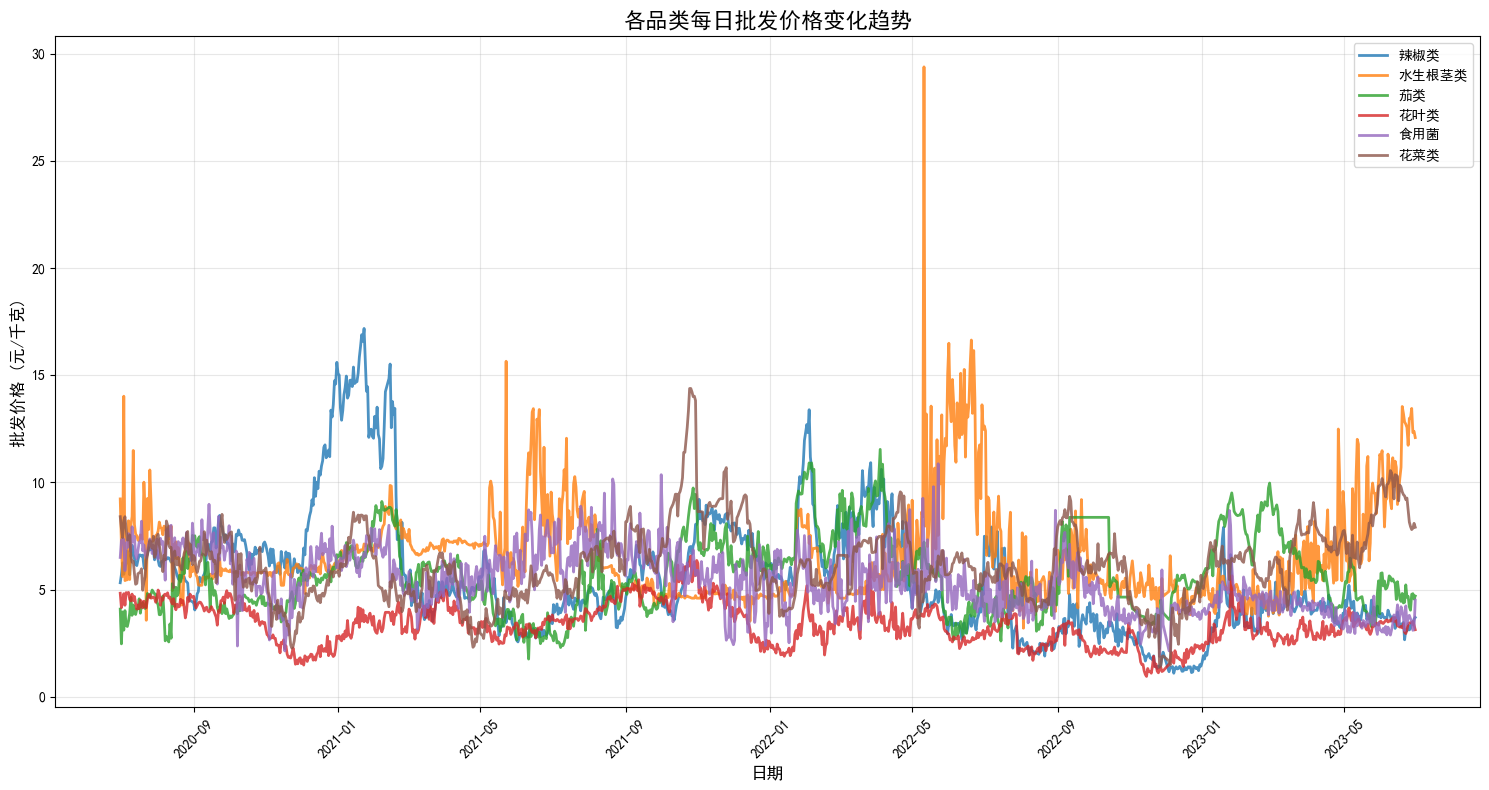


各品类每日批发价格数据预览:
             辣椒类  水生根茎类    茄类   花叶类   食用菌   花菜类
2020-07-01  5.32   9.23  4.09  4.83  6.50  8.40
2020-07-02  5.70   7.09  2.47  4.16  7.31  7.84
2020-07-03  6.25   5.61  3.96  4.39  7.36  7.43
2020-07-04  5.71  14.02  3.11  4.81  7.34  8.22
2020-07-05  6.04   5.42  4.02  4.27  5.89  8.40
2020-07-06  6.22   5.45  3.32  4.86  7.18  7.82
2020-07-07  6.81   5.46  3.28  4.81  6.96  7.31
2020-07-08  6.45   8.21  3.53  4.87  7.61  7.34
2020-07-09  5.69   5.47  3.90  4.54  7.21  7.55
2020-07-10  6.61   7.98  4.64  4.47  6.77  6.55

📁 结果已保存到: 各品类每日批发价格.xlsx

💡 数据说明:
• 使用销量作为权重计算加权平均价格
• 加权平均价格 = Σ(单品价格 × 单品销量) / Σ(单品销量)
• 对于缺失价格的日期，使用前向填充方法
• 价格数据已保存在 category_daily_prices 变量中


In [18]:
from tqdm import tqdm
import pandas as pd

print("计算各品类每日加权平均批发价格")
print("=" * 60)

# 合并df2和df3，获取每日销售数据和对应的批发价格
# df2: 销售数据 (日期、单品编码、销量)
# df3: 批发价格数据 (日期、单品编码、批发价格)

# 先检查df3的数据结构
print("批发价格数据(df3)结构:")
print(f"形状: {df3.shape}")
print(f"列名: {df3.columns.tolist()}")
print("\n前5行数据:")
print(df3.head())

# 合并销售数据和价格数据
merged_data = pd.merge(
    df2, 
    df3, 
    on=['销售日期', '单品编码'], 
    how='inner'  # 只保留有价格信息的销售记录
)

print(f"\n合并后数据形状: {merged_data.shape}")
print(f"原始销售记录: {len(df2)}")
print(f"有价格信息的销售记录: {len(merged_data)}")

# 创建各品类每日加权平均批发价DataFrame
daily_wholesale_prices = pd.DataFrame(
    index=pd.to_datetime(all_dates),
    columns=all_categories
)

print("\n开始计算各品类每日加权平均批发价格...")

# 按日期和品类分组计算加权平均价格
for date in tqdm(all_dates, desc="处理日期"):
    # 筛选当日数据
    daily_data = merged_data[merged_data['销售日期'] == date]
    
    if len(daily_data) == 0:
        continue
    
    # 为每条记录添加品类信息
    daily_data = daily_data.copy()
    daily_data['品类'] = daily_data['单品编码'].map(dpbm_to_flmc)
    
    # 按品类分组计算加权平均价格
    for category in all_categories:
        category_data = daily_data[daily_data['品类'] == category]
        
        if len(category_data) > 0 and category_data['销量(千克)'].sum() > 0:
            # 计算加权平均价格：(价格 × 销量) / 总销量
            weighted_price = (
                category_data['批发价格(元/千克)'] * category_data['销量(千克)']
            ).sum() / category_data['销量(千克)'].sum()
            
            daily_wholesale_prices.loc[date, category] = round(weighted_price, 2)

# 填充缺失值 - 使用前向填充
daily_wholesale_prices = daily_wholesale_prices.fillna(method='ffill')

print("\n✅ 计算完成！")
print(f"各品类每日批发价格数据形状: {daily_wholesale_prices.shape}")

# 显示统计摘要
print("\n各品类批发价格统计摘要:")
print("=" * 60)
for category in all_categories:
    if category in daily_wholesale_prices.columns:
        prices = daily_wholesale_prices[category].dropna()
        if len(prices) > 0:
            print(f"\n{category}:")
            print(f"  有效价格天数: {len(prices)}")
            print(f"  平均价格: {prices.mean():.2f} 元/千克")
            print(f"  价格范围: {prices.min():.2f} - {prices.max():.2f} 元/千克")
            print(f"  价格标准差: {prices.std():.2f} 元/千克")

# 可视化价格趋势
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
for category in all_categories:
    if category in daily_wholesale_prices.columns:
        prices = daily_wholesale_prices[category].dropna()
        if len(prices) > 0:
            plt.plot(prices.index, prices.values, label=category, linewidth=2, alpha=0.8)

plt.title('各品类每日批发价格变化趋势', fontsize=16)
plt.xlabel('日期', fontsize=12)
plt.ylabel('批发价格 (元/千克)', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 显示前几行结果
print("\n各品类每日批发价格数据预览:")
print("=" * 60)
print(daily_wholesale_prices.head(10))

# 保存结果
daily_wholesale_prices.to_excel('各品类每日批发价格.xlsx')
print("\n📁 结果已保存到: 各品类每日批发价格.xlsx")

# 将结果存储到变量中供后续使用
category_daily_prices = daily_wholesale_prices

print(f"\n💡 数据说明:")
print(f"• 使用销量作为权重计算加权平均价格")
print(f"• 加权平均价格 = Σ(单品价格 × 单品销量) / Σ(单品销量)")
print(f"• 对于缺失价格的日期，使用前向填充方法")
print(f"• 价格数据已保存在 category_daily_prices 变量中")

🚀 开始使用 Prophet 模型预测批发价格...

【花叶类】价格预测:
----------------------------------------
  数据最后日期: 2023-06-30
  预测目标期间: 2023-07-01 到 2023-07-07


15:18:31 - cmdstanpy - INFO - Chain [1] start processing
15:18:31 - cmdstanpy - INFO - Chain [1] done processing


  需要预测的天数: 7 天
  ✅ 花叶类 预测完成，获得 7 个预测点

【花菜类】价格预测:
----------------------------------------
  数据最后日期: 2023-06-30
  预测目标期间: 2023-07-01 到 2023-07-07


15:18:31 - cmdstanpy - INFO - Chain [1] start processing
15:18:31 - cmdstanpy - INFO - Chain [1] done processing


  需要预测的天数: 7 天
  ✅ 花菜类 预测完成，获得 7 个预测点

【水生根茎类】价格预测:
----------------------------------------
  数据最后日期: 2023-06-30
  预测目标期间: 2023-07-01 到 2023-07-07


...

  需要预测的天数: 7 天
  ✅ 茄类 预测完成，获得 7 个预测点

【辣椒类】价格预测:
----------------------------------------
  数据最后日期: 2023-06-30
  预测目标期间: 2023-07-01 到 2023-07-07


15:18:32 - cmdstanpy - INFO - Chain [1] start processing
15:18:33 - cmdstanpy - INFO - Chain [1] done processing


  需要预测的天数: 7 天
  ✅ 辣椒类 预测完成，获得 7 个预测点

【食用菌】价格预测:
----------------------------------------
  数据最后日期: 2023-06-30
  预测目标期间: 2023-07-01 到 2023-07-07


15:18:33 - cmdstanpy - INFO - Chain [1] start processing
15:18:33 - cmdstanpy - INFO - Chain [1] done processing


  需要预测的天数: 7 天
  ✅ 食用菌 预测完成，获得 7 个预测点

📅 2023年7月1日至7日批发价格预测结果 (元/千克):
             花叶类   花菜类  水生根茎类    茄类   辣椒类   食用菌
日期                                             
2023-07-01  3.44  8.71   9.77  3.77  4.84  3.84
2023-07-02  3.43  8.65   9.63  3.80  4.95  3.82
2023-07-03  3.39  8.58   9.36  3.69  4.99  3.81
2023-07-04  3.39  8.54   9.19  3.61  5.22  3.90
2023-07-05  3.40  8.61   9.06  3.64  5.40  3.75
2023-07-06  3.42  8.59   8.74  3.58  5.46  3.70
2023-07-07  3.43  8.54   8.52  3.56  5.54  3.73

📁 预测结果已保存到: 2023年7月批发价格预测结果.xlsx

📈 预测结果可视化:


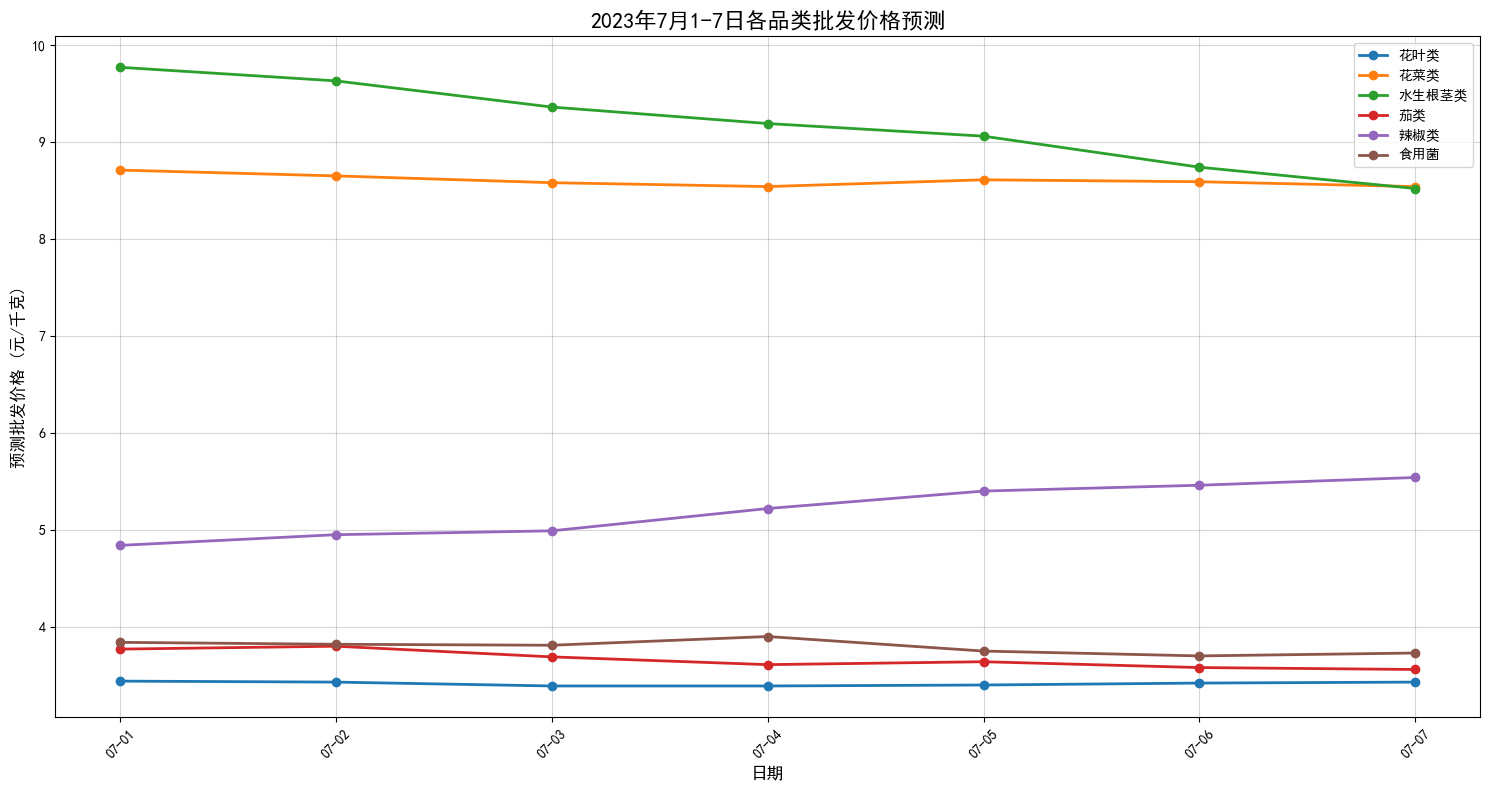


📊 预测结果统计分析:

花叶类:
  平均价格: 3.41 元/千克
  价格范围: 3.39 - 3.44 元/千克
  价格波动: 0.02 元/千克
  价格趋势: -下降

花菜类:
  平均价格: 8.60 元/千克
  价格范围: 8.54 - 8.71 元/千克
  价格波动: 0.06 元/千克
  价格趋势: -下降

水生根茎类:
  平均价格: 9.18 元/千克
  价格范围: 8.52 - 9.77 元/千克
  价格波动: 0.45 元/千克
  价格趋势: -下降

茄类:
  平均价格: 3.66 元/千克
  价格范围: 3.56 - 3.80 元/千克
  价格波动: 0.09 元/千克
  价格趋势: -下降

辣椒类:
  平均价格: 5.20 元/千克
  价格范围: 4.84 - 5.54 元/千克
  价格波动: 0.28 元/千克
  价格趋势: +上升

食用菌:
  平均价格: 3.79 元/千克
  价格范围: 3.70 - 3.90 元/千克
  价格波动: 0.07 元/千克
  价格趋势: -下降

💡 说明:
• 使用Prophet时间序列模型进行价格预测
• 模型考虑了季节性、趋势和节假日效应
• 预测基于历史价格数据的模式识别
• 结果已保存为Excel文件便于后续分析


In [19]:
# 通过prophet模型预测2023年7月1日到7日共7天，六种品类的批发价格

try:
    from prophet import Prophet
    import warnings
    warnings.filterwarnings('ignore')

    print("🚀 开始使用 Prophet 模型预测批发价格...")
    print("=" * 80)

    # 1. 准备数据和定义参数
    # 确保 category_daily_prices 存在且是 DataFrame
    if 'category_daily_prices' not in locals() or not isinstance(category_daily_prices, pd.DataFrame):
        raise NameError("`category_daily_prices` 变量不存在或不是有效的数据帧。请先运行前面的单元格计算每日批发价格。")

    # 选择要预测的6个品类
    prediction_categories = ['花叶类', '花菜类', '水生根茎类', '茄类', '辣椒类', '食用菌']
    
    # 检查品类是否存在
    available_categories = [cat for cat in prediction_categories if cat in category_daily_prices.columns]
    if len(available_categories) == 0:
        print(f"⚠️ 错误: 所选品类都不存在于价格数据中")
        print(f"可用品类: {list(category_daily_prices.columns)}")
        raise ValueError("无可预测的品类")
    
    if len(available_categories) < len(prediction_categories):
        print(f"⚠️ 警告: 部分品类不存在，将对以下存在的品类进行预测: {available_categories}")
    
    prediction_categories = available_categories

    # 预测时间范围
    start_date = '2023-07-01'
    end_date = '2023-07-07'

    # 存储预测结果
    all_forecasts = {}

    # 2. 循环为每个品类建模和预测
    for category in prediction_categories:
        print(f"\n【{category}】价格预测:")
        print("-" * 40)
        
        # 准备Prophet数据格式
        prophet_data = category_daily_prices[[category]].dropna().reset_index()
        prophet_data.columns = ['ds', 'y']
        prophet_data['ds'] = pd.to_datetime(prophet_data['ds'])
        
        if len(prophet_data) < 10:
            print(f"  ❌ 数据点太少 ({len(prophet_data)}个)，无法进行有效预测。")
            continue
            
        # 获取数据最后日期
        last_date = prophet_data['ds'].max()
        target_start = pd.to_datetime(start_date)
        target_end = pd.to_datetime(end_date)
        
        print(f"  数据最后日期: {last_date.strftime('%Y-%m-%d')}")
        print(f"  预测目标期间: {target_start.strftime('%Y-%m-%d')} 到 {target_end.strftime('%Y-%m-%d')}")

        # 创建Prophet模型
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            seasonality_mode='additive',
            changepoint_prior_scale=0.1, # 增加灵活性以适应价格波动
            seasonality_prior_scale=10.0
        )
        
        try:
            # 训练模型
            model.fit(prophet_data)
            
            # 创建未来日期框架
            if target_end <= last_date:
                print(f"  ⚠️ 目标日期在历史数据范围内，直接从历史数据提取")
                # 直接从历史数据中筛选
                target_forecast = prophet_data[
                    (prophet_data['ds'] >= target_start) & 
                    (prophet_data['ds'] <= target_end)
                ].copy()
                # 为了统一格式，将 'y' 列重命名为 'yhat'
                target_forecast.rename(columns={'y': 'yhat'}, inplace=True)
            else:
                periods_to_forecast = (target_end - last_date).days
                print(f"  需要预测的天数: {periods_to_forecast} 天")
                future = model.make_future_dataframe(periods=periods_to_forecast)
                # 进行预测
                forecast_df = model.predict(future)
                # 筛选出目标预测区间的数据
                target_forecast = forecast_df[
                    (forecast_df['ds'] >= target_start) & 
                    (forecast_df['ds'] <= target_end)
                ]

            all_forecasts[category] = target_forecast
            print(f"  ✅ {category} 预测完成，获得 {len(target_forecast)} 个预测点")
            
        except Exception as e:
            print(f"  ❌ 建模失败: {str(e)}")
            continue

    # 3. 整合和展示结果
    print("\n" + "="*80)
    print(f"📅 2023年7月1日至7日批发价格预测结果 (元/千克):")
    print("="*80)

    if all_forecasts:
        # 创建结果DataFrame
        date_range = pd.date_range(start=start_date, end=end_date)
        result_df = pd.DataFrame(index=date_range)
        result_df.index.name = '日期'
        
        for category, forecast in all_forecasts.items():
            # 使用 'ds' 和 'yhat' 列创建 Series
            forecast_series = pd.Series(
                forecast['yhat'].values, 
                index=pd.to_datetime(forecast['ds'])
            )
            # 重新索引以确保所有日期都包含
            forecast_series = forecast_series.reindex(date_range)
            result_df[category] = forecast_series.round(2) # 保留两位小数

        # 打印结果表格
        print(result_df)
        
        # 4. 保存结果到Excel
        output_filename = '2023年7月批发价格预测结果.xlsx'
        result_df.to_excel(output_filename)
        print(f"\n📁 预测结果已保存到: {output_filename}")

        # 5. 可视化预测结果
        print("\n" + "="*80)
        print("📈 预测结果可视化:")
        print("="*80)
        
        plt.figure(figsize=(15, 8))
        
        for category in result_df.columns:
            if not result_df[category].isna().all():  # 只绘制有数据的品类
                plt.plot(result_df.index, result_df[category], 
                        marker='o', linestyle='-', linewidth=2,
                        label=f'{category}', markersize=6)

        plt.title('2023年7月1-7日各品类批发价格预测', fontsize=16)
        plt.xlabel('日期', fontsize=12)
        plt.ylabel('预测批发价格 (元/千克)', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.5)
        plt.xticks(result_df.index, result_df.index.strftime('%m-%d'), rotation=45)
        plt.tight_layout()
        plt.show()

        # 6. 统计分析
        print("\n" + "="*60)
        print("📊 预测结果统计分析:")
        print("="*60)
        
        for category in result_df.columns:
            if not result_df[category].isna().all():
                prices = result_df[category].dropna()
                print(f"\n{category}:")
                print(f"  平均价格: {prices.mean():.2f} 元/千克")
                print(f"  价格范围: {prices.min():.2f} - {prices.max():.2f} 元/千克")
                print(f"  价格波动: {prices.std():.2f} 元/千克")
                print(f"  价格趋势: {'+上升' if prices.iloc[-1] > prices.iloc[0] else '-下降' if prices.iloc[-1] < prices.iloc[0] else '=平稳'}")

    else:
        print("❌ 未能生成任何预测结果。")

    print(f"\n💡 说明:")
    print(f"• 使用Prophet时间序列模型进行价格预测")
    print(f"• 模型考虑了季节性、趋势和节假日效应")
    print(f"• 预测基于历史价格数据的模式识别")
    print(f"• 结果已保存为Excel文件便于后续分析")

except ImportError:
    print("=" * 80)
    print("❌ 错误: 未安装 Prophet 库")
    print("=" * 80)
    print("请先安装 Prophet 库:")
    print("  方法1: pip install prophet")
    print("  方法2: conda install -c conda-forge prophet")
    print("安装后重新运行此单元格即可。")
    
except NameError as e:
    print("=" * 80)
    print(f"❌ 错误: {e}")
    print("=" * 80)
    print("请确保先运行前面计算各品类每日批发价格的单元格。")
    
except Exception as e:
    print(f"❌ 发生未知错误: {e}")
    print("请检查数据格式和代码逻辑。")

In [20]:
df4 = pd.read_csv('附件4.csv', encoding='gb2312')
df4

,单品编码,单品名称,损耗率(%)
0,102900005115168,牛首生菜,4.39
1,102900005115199,四川红香椿,10.46
2,102900005115250,西峡花菇(1),10.80
3,102900005115625,本地小毛白菜,0.18
4,102900005115748,白菜苔,8.78
...,...,...,...
246,106971533455008,海鲜菇(袋)(3),1.30
247,106971563780002,鲜粽叶(袋)(2),0.00
248,106972776821582,鲜粽叶(袋)(3),9.43
249,106973223300667,虫草花(盒)(2),11.13


In [21]:
df4_old = pd.read_excel('附件4.xlsx', sheet_name='Sheet1')
df4_old

,单品编码,单品名称,损耗率(%)
0,102900005115168,牛首生菜,4.39
1,102900005115199,四川红香椿,10.46
2,102900005115250,西峡花菇(1),10.80
3,102900005115625,本地小毛白菜,0.18
4,102900005115748,白菜苔,8.78
...,...,...,...
246,106971533455008,海鲜菇(袋)(3),1.30
247,106971563780002,鲜粽叶(袋)(2),0.00
248,106972776821582,鲜粽叶(袋)(3),9.43
249,106973223300667,虫草花(盒)(2),11.13
